<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>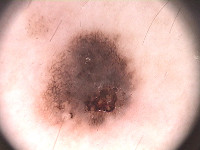</td><td>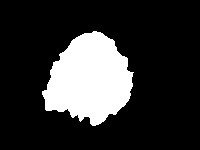</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

In [2]:
# get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False, order=0, preserve_range=True) > 0.5 for y in lesions]



In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

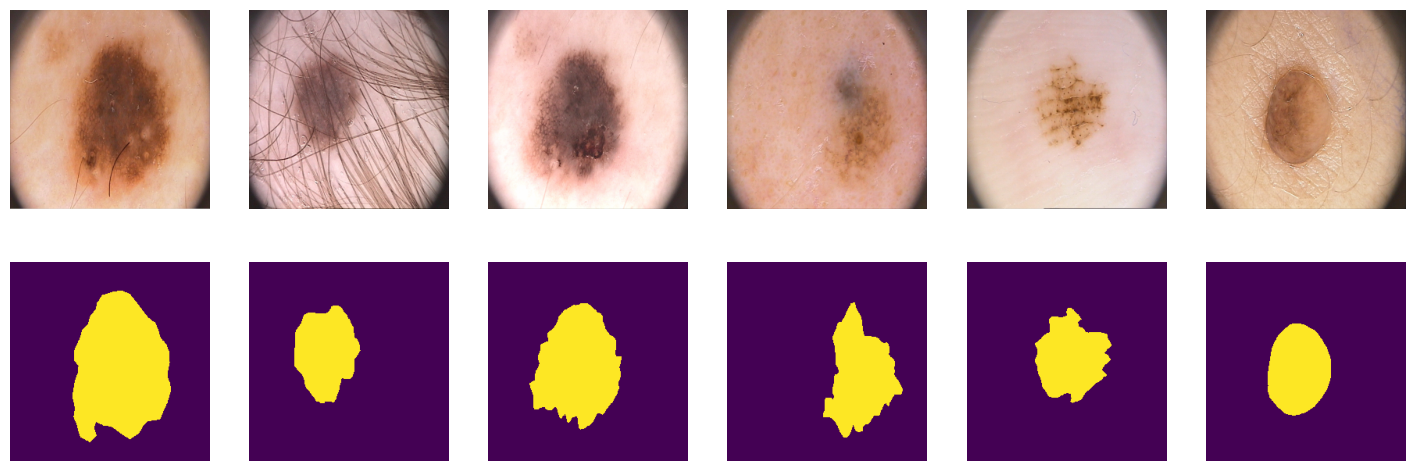

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на ~~100/50/50~~ 160/20/20 (100 маловато для обучения)
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [160, 180])

In [8]:
print(len(tr), len(val), len(ts))

160 20 20


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





![](https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN)

In [11]:
# !pip install torchmetrics

In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(DEVICE)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

---

**Ответ:** 

По сути, по ссылке https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits уже написан вывод одного из другого, но с другими обозначениями. 

Знак суммы убираем, переписав выражение в векторном виде:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

Раскрываем сигмоиду:

$y \cdot -\log\left(\frac{1}{1 + e^{-\hat y}}\right)+ (1 - y)\cdot -\log\left(\frac{e^{-\hat y}}{1 + e^{-\hat y}}\right)$

Играем со свойствами логарифма и избавляемся от дробей и минусов:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(-\log(e^{-\hat y}) + \log(1 + e^{-\hat y})\right)$

Раскрываем тривиальный логарифм от экспоненты:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(\hat y + \log(1 + e^{-\hat y})\right)$

Раскрываем скобки и сокращаем множитель у логарифмов, остается 1 штука логарифма:

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

И еще раз раскрываем скобки:

$\hat y - \hat y y + \log(1 + e^{-\hat y})$

---

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

Еще раз формулы, чтобы глазами не бегать выше:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

In [15]:
def bce_loss(y_pred, y_real):
    eps = 1e-12
    y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()

def bce_true(y_pred, y_real):
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()

Проверим корректность работы на простом примере

In [16]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный      = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch            = 5.732497692108154
BCE loss честно посчитанный      = 5.732497215270996
BCE loss from torch              = 5.732497692108154
BCE loss from torch with logits  = 5.732497215270996


C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [17]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.526735305786133
BCE loss честно посчитанный               = 14.526735305786133
BCE loss from torch bce_torch             = 14.52673625946045
BCE loss from torch with logits bce_torch = 14.526737213134766


C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

In [21]:
path_to_dummy_samples = './for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(DEVICE)
dummpy_sample['logits'] = dummpy_sample['logits'].to(DEVICE)

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\3484867643.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dummpy_sample = {'logits': torch.load(f'{path_to_du

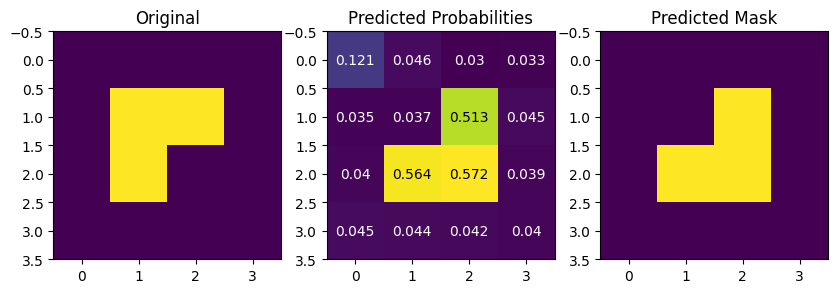

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [23]:
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

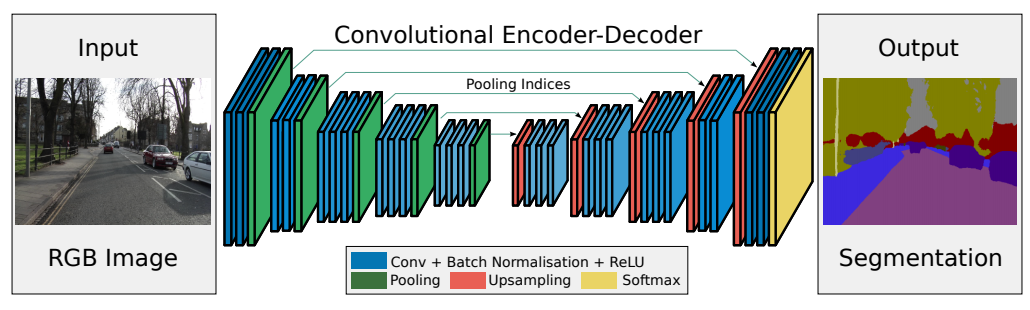

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [25]:
# model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [26]:
# model_vgg16

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [27]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True, reduce_channels_at='tail'):
        super(DecoderBlock, self).__init__() 
        
        if reduce_channels_at not in ('head', 'tail'):
            raise ValueError(f"reduce_channels_at should be 'head' or 'tail', got: {reduce_channels_at}")
        
        self.upsampling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        
        self.layers = nn.ModuleList()

        curr_channels = in_channels
        if reduce_channels_at == 'head':  # задел под переиспользование блоков в UNet
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            curr_channels = out_channels
            self.layers.append(nn.BatchNorm2d(curr_channels))
            self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = curr_channels, out_channels = curr_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(curr_channels))
            self.layers.append(nn.ReLU(inplace=True))

        if reduce_channels_at == 'tail':
            self.layers.append(nn.Conv2d(in_channels = curr_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        if not tail_activation:
            del self.layers[-2:]

    def forward(self, x, max_indices):
        x = self.upsampling(x, max_indices)
        
        for layer in self.layers:
            x = layer(x)
        
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [29]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        self.encoders = nn.ModuleList([
            EncoderBlock(in_channels, num_features, depth=2),
            EncoderBlock(num_features, num_features * 2, depth=2),
            EncoderBlock(num_features * 2, num_features * 4, depth=3),
            EncoderBlock(num_features * 4, num_features * 8, depth=3),
            EncoderBlock(num_features * 8, num_features * 8, depth=3) # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        ])

        self.decoders = nn.ModuleList([
            DecoderBlock(num_features * 8, num_features * 8, depth=3), # Decoder bottleneck
            DecoderBlock(num_features * 8, num_features * 4, depth=3),
            DecoderBlock(num_features * 4, num_features * 2, depth=3),
            DecoderBlock(num_features * 2, num_features, depth=2),
            DecoderBlock(num_features, out_channels, depth=2, tail_activation=False)
        ])


    def forward(self, x):
        max_pooling_indices = []
        for encoder in self.encoders:
            x, indices = encoder(x)
            max_pooling_indices.append(indices)

        for decoder, indices in zip(self.decoders, reversed(max_pooling_indices)):
            x = decoder(x, indices)

        return x  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [30]:
from tqdm.notebook import tqdm

In [31]:
NUM_WORKERS = 1

In [32]:
def fit_epoch(model, train_loader, criterion, optimizer):
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

    train_loss = running_loss / processed_batches
    train_acc = running_corrects.cpu().numpy() / processed_pixels
    return train_loss, train_acc

In [33]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

    val_loss = running_loss / processed_batches
    val_acc = running_corrects.double() / processed_pixels
    return val_loss, val_acc

In [34]:
import time

In [ ]:
def train(train_dataset, val_dataset, model, epochs, batch_size, criterion, optimizer=None, cb_checkpoint=None, model_name='model'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    start_time = time.time()
    history = []
    log_template = "\nEpoch {ep:03d}  |  Loss T:{t_loss:0.4f} \
V:{v_loss:0.4f}  |  Accuracy T:{t_acc:0.4f}, V:{v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters())
        else:
            pass 

        best_val_loss = 999999.9
        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'elapsed_time_sec': time.time() - start_time,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_loss': val_loss, 
                    'val_acc': val_acc, 
                }, f"best_{model_name}.pth")

            if (epoch + 1) % 16 == 0:
                if cb_checkpoint is not None:
                    cb_checkpoint(history)
                
                torch.save({
                    'epoch': epoch,
                    'elapsed_time_sec': time.time() - start_time,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_loss': val_loss, 
                    'val_acc': val_acc, 
                }, f"checkpoint_{epoch}_{model_name}.pth")

    return history

In [75]:
def plot_epoch_loss(history, ax=None):
    loss, acc, val_loss, val_acc = zip(*history)

    if ax is None:
        ax = plt.gca()

    ax.plot(loss, label="train_loss")
    ax.plot(val_loss, label="val_loss")
    ax.legend(loc='best')
    ax.set_xlabel("epochs")
    ax.set_ylabel("loss")


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [37]:
from torch.utils.data import TensorDataset

def to_tensor_dataset(x, y):
    x_np = np.rollaxis(x, 3, 1).astype(np.float32)   # (N, C, H, W)
    y_np = y[:, np.newaxis].astype(np.float32)       # (N, 1, H, W) 

    X_t = torch.from_numpy(x_np)
    Y_t = torch.from_numpy(y_np)

    return TensorDataset(X_t, Y_t)

train_dataset = to_tensor_dataset(X[tr], Y[tr])
val_dataset = to_tensor_dataset(X[val], Y[val])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

In [38]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
import gc

def cleanup_models():
    for name, obj in list(globals().items()):
        if isinstance(obj, torch.nn.Module) and 'model' in name:
            del globals()[name]

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()


In [39]:
cleanup_models()

In [40]:
bce_mean = nn.BCEWithLogitsLoss(reduction='mean')

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.5305 V:0.6608  |  Accuracy T:0.7447, V:0.5949

Epoch 002  |  Loss T:0.6193 V:0.7481  |  Accuracy T:0.6708, V:0.5949

Epoch 003  |  Loss T:0.6196 V:0.5907  |  Accuracy T:0.7049, V:0.7019

Epoch 004  |  Loss T:0.4799 V:0.4644  |  Accuracy T:0.8097, V:0.8238

Epoch 005  |  Loss T:0.3960 V:0.4851  |  Accuracy T:0.8271, V:0.8376

Epoch 006  |  Loss T:0.3189 V:0.4045  |  Accuracy T:0.8768, V:0.8657

Epoch 007  |  Loss T:0.3010 V:0.3693  |  Accuracy T:0.8823, V:0.8822

Epoch 008  |  Loss T:0.2770 V:0.4235  |  Accuracy T:0.8941, V:0.8732

Epoch 009  |  Loss T:0.3091 V:0.4129  |  Accuracy T:0.8696, V:0.8709

Epoch 010  |  Loss T:0.3233 V:0.6395  |  Accuracy T:0.8839, V:0.7397

Epoch 011  |  Loss T:0.3799 V:0.4530  |  Accuracy T:0.8480, V:0.8253

Epoch 012  |  Loss T:0.2931 V:0.4135  |  Accuracy T:0.8886, V:0.8875

Epoch 013  |  Loss T:0.2424 V:0.3761  |  Accuracy T:0.9044, V:0.8995

Epoch 014  |  Loss T:0.3059 V:0.3913  |  Accuracy T:0.8863, V:0.8503

Epoch 015  |  Loss 

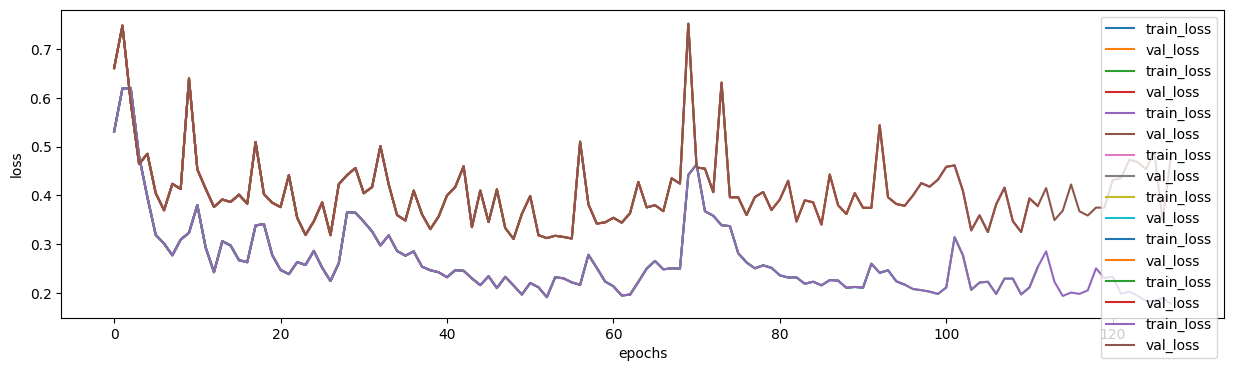

In [87]:
model = SegNet().to(DEVICE)

history = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=model, 
    epochs=128, 
    batch_size=16, 
    criterion=bce_mean,
    optimizer=torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

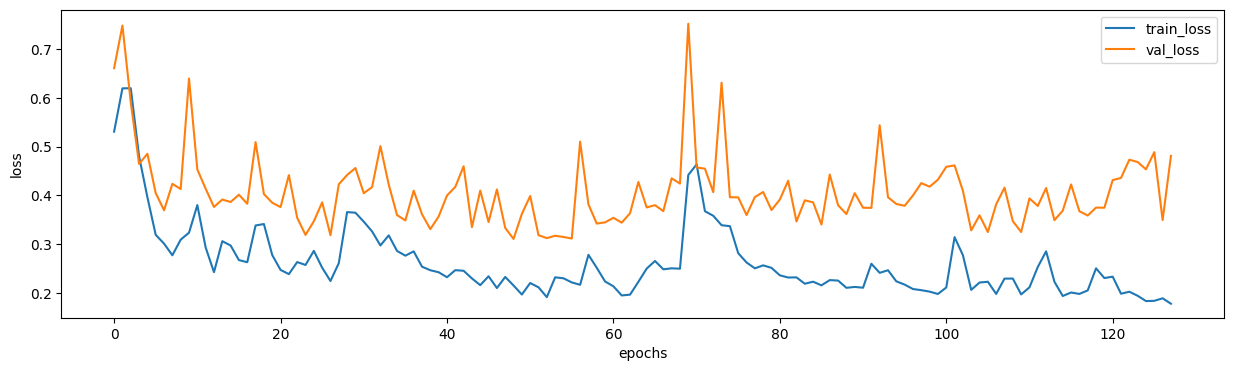

In [88]:
plot_epoch_loss(history)

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [41]:
cleanup_models()

In [42]:
test_dataset = to_tensor_dataset(X[ts], Y[ts])
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)

In [43]:
def test(model, val_loader, criterion):
    iou_score.reset()
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += inputs.numel()
        processed_batches += 1

        iou_score.update(preds, labels)

    avg_loss = running_loss / processed_batches
    avg_acc = running_corrects.double() / processed_pixels
    return avg_loss, avg_acc

In [44]:
def test_model_checkpoint(cp, model, criterion):
    try:
        checkpoint = torch.load(cp, map_location=DEVICE)
    except:
        print(f"No such checkpoint: {cp}")
        return

    model = model().to(DEVICE)
    model.load_state_dict(checkpoint["model_state"])

    test_loss, test_acc = test(model, test_loader, criterion=criterion)
    print(f'\n----- ----- {cp} ----- -----')
    print(f'Epoch: {checkpoint["epoch"]}')
    if "elapsed_time_sec" in checkpoint:
        print(f'Elapsed time: {checkpoint["elapsed_time_sec"]} sec.')
    print(f'Test loss: {test_loss}, test accuracy: {test_acc}')
    print(f'Test IoU: {iou_score.compute()}')

In [89]:
cleanup_models()
test_model_checkpoint("best_model.pth", model=SegNet, criterion=bce_mean)
cleanup_models()

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\2410446969.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)



----- ----- best_model.pth ----- -----
Epoch: 48
Elapsed time: 442.52898931503296 sec.
Test loss: 0.3248785436153412, test accuracy: 0.2930608113606771
Test IoU: 0.6938391923904419


# Задания: Мир других лососов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [46]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    probs = F.sigmoid(logits)
    preds = (probs > threshold).to(int)

    tp = ((preds == 1) & (labels == 1)).sum() / labels.size(1)
    fp = ((preds == 1) & (labels == 0)).sum() / labels.size(1)
    fn = ((preds == 0) & (labels == 1)).sum() / labels.size(1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return score

Проверим на корректность функцию dice_score:

In [47]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(DEVICE)
dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))

c:\Users\Efim Plotnikov\PycharmProjects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.6667, device='cuda:0')

In [49]:
dice_torch = dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))
dice_custom = dice_score(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
print(dice_torch, dice_custom)
assert dice_torch == dice_custom

tensor(0.6667, device='cuda:0') tensor(0.6667, device='cuda:0')


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

In [50]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    logits = torch.clamp(logits, -20, 20) # HACK: sigmoid is oversaturated otherwise
    probs = F.sigmoid(logits)
    probs = probs.flatten(1)
    labels = labels.flatten(1)

    tp = (probs * labels).sum(dim=1)
    fp = (probs * (1 - labels)).sum(dim=1)
    fn = ((1 - probs) * labels).sum(dim=1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return 1 - score.mean()

Проверка на корректность:

In [51]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [53]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [54]:
loss_torch = dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
loss_custom = dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])
print(loss_torch, loss_custom)
assert loss_torch == loss_custom

tensor(0.5756, device='cuda:0') tensor(0.5756, device='cuda:0')


**Ассерты проходят, всё хорошо**

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [55]:
def focal_loss(y_pred, y_real, eps = 1e-8, gamma = 2, reduction='mean'):
    prob = torch.sigmoid(y_pred)
    p_t = prob * y_real + (1 - prob) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction="none")
    modulating_factor = (1.0 - p_t) ** gamma
    loss = modulating_factor * bce

    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    
    return loss

Проверка корректности функции:

In [56]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')

tensor(0.2260, device='cuda:0')

In [57]:
torch_focal = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')
custom_focal = focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2.0, reduction='mean')
print(torch_focal, "\n", custom_focal)
assert torch_focal == custom_focal

tensor(0.2260, device='cuda:0') 
 tensor(0.2260, device='cuda:0')


**Все ассерты прошли, всё хорошо**

---

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [58]:
# TODO

---

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.4368 V:0.6190  |  Accuracy T:0.7610, V:0.6375

Epoch 002  |  Loss T:0.5556 V:0.4296  |  Accuracy T:0.4918, V:0.4051

Epoch 003  |  Loss T:0.5297 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 004  |  Loss T:0.5343 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 005  |  Loss T:0.5294 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 006  |  Loss T:0.5297 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 007  |  Loss T:0.5342 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 008  |  Loss T:0.5308 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 009  |  Loss T:0.5322 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 010  |  Loss T:0.5328 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 011  |  Loss T:0.5319 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 012  |  Loss T:0.5321 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 013  |  Loss T:0.5314 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 014  |  Loss T:0.5295 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 015  |  Loss 

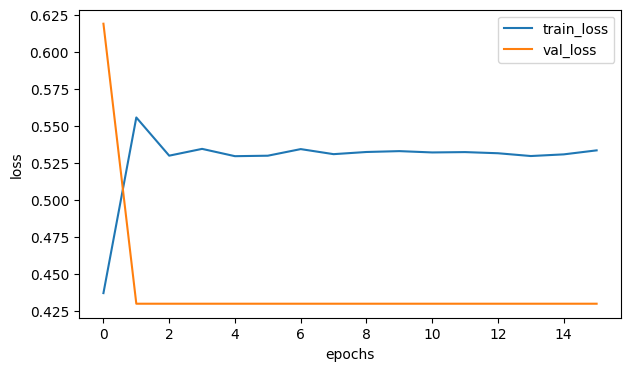


Epoch 017  |  Loss T:0.5297 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 018  |  Loss T:0.5297 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 019  |  Loss T:0.5290 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 020  |  Loss T:0.5292 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 021  |  Loss T:0.5334 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 022  |  Loss T:0.5342 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 023  |  Loss T:0.5304 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 024  |  Loss T:0.5330 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 025  |  Loss T:0.5287 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 026  |  Loss T:0.5355 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 027  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 028  |  Loss T:0.5340 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 029  |  Loss T:0.5298 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 030  |  Loss T:0.5319 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 031  |  Loss 

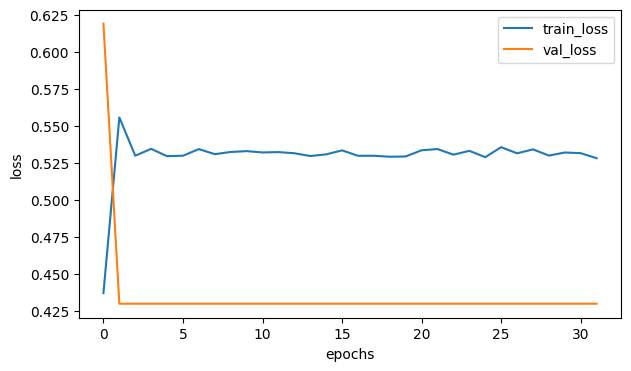


Epoch 033  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 034  |  Loss T:0.5288 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 035  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 036  |  Loss T:0.5311 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 037  |  Loss T:0.5287 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 038  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 039  |  Loss T:0.5331 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 040  |  Loss T:0.5292 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 041  |  Loss T:0.5299 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 042  |  Loss T:0.5328 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 043  |  Loss T:0.5316 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 044  |  Loss T:0.5303 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 045  |  Loss T:0.5324 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 046  |  Loss T:0.5339 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 047  |  Loss 

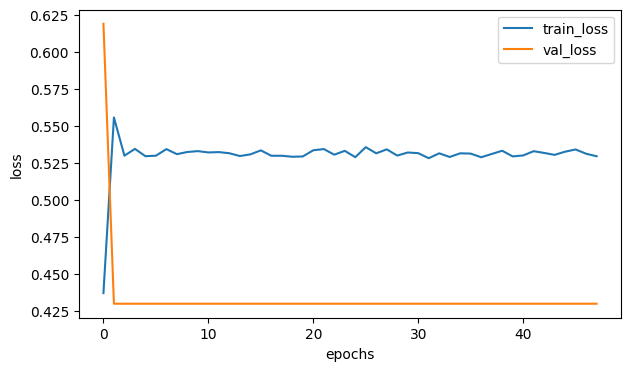


Epoch 049  |  Loss T:0.5322 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 050  |  Loss T:0.5300 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 051  |  Loss T:0.5333 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 052  |  Loss T:0.5319 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 053  |  Loss T:0.5298 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 054  |  Loss T:0.5318 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 055  |  Loss T:0.5314 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 056  |  Loss T:0.5300 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 057  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 058  |  Loss T:0.5283 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 059  |  Loss T:0.5323 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 060  |  Loss T:0.5335 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 061  |  Loss T:0.5289 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 062  |  Loss T:0.5311 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 063  |  Loss 

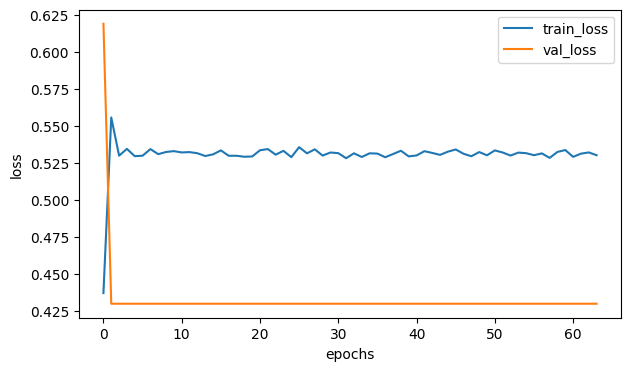


Epoch 065  |  Loss T:0.5299 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 066  |  Loss T:0.5308 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 067  |  Loss T:0.5319 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 068  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 069  |  Loss T:0.5315 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 070  |  Loss T:0.5355 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 071  |  Loss T:0.5334 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 072  |  Loss T:0.5325 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 073  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 074  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 075  |  Loss T:0.5311 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 076  |  Loss T:0.5287 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 077  |  Loss T:0.5287 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 078  |  Loss T:0.5294 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 079  |  Loss 

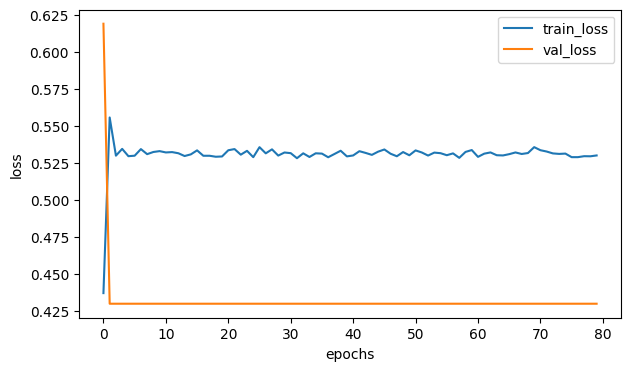


Epoch 081  |  Loss T:0.5308 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 082  |  Loss T:0.5300 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 083  |  Loss T:0.5324 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 084  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 085  |  Loss T:0.5360 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 086  |  Loss T:0.5313 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 087  |  Loss T:0.5330 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 088  |  Loss T:0.5323 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 089  |  Loss T:0.5297 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 090  |  Loss T:0.5342 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 091  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 092  |  Loss T:0.5335 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 093  |  Loss T:0.5320 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 094  |  Loss T:0.5307 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 095  |  Loss 

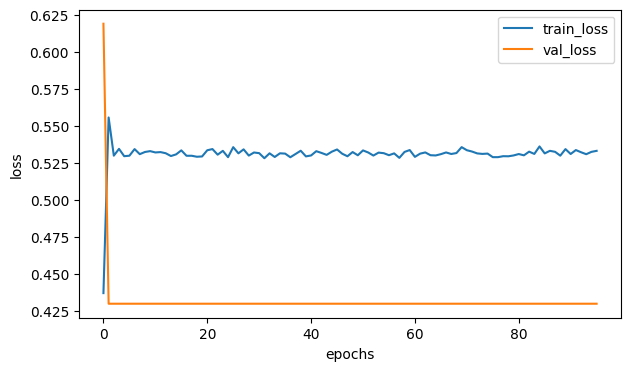


Epoch 097  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 098  |  Loss T:0.5295 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 099  |  Loss T:0.5316 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 100  |  Loss T:0.5286 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 101  |  Loss T:0.5345 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 102  |  Loss T:0.5322 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 103  |  Loss T:0.5309 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 104  |  Loss T:0.5300 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 105  |  Loss T:0.5327 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 106  |  Loss T:0.5292 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 107  |  Loss T:0.5299 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 108  |  Loss T:0.5320 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 109  |  Loss T:0.5283 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 110  |  Loss T:0.5302 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 111  |  Loss 

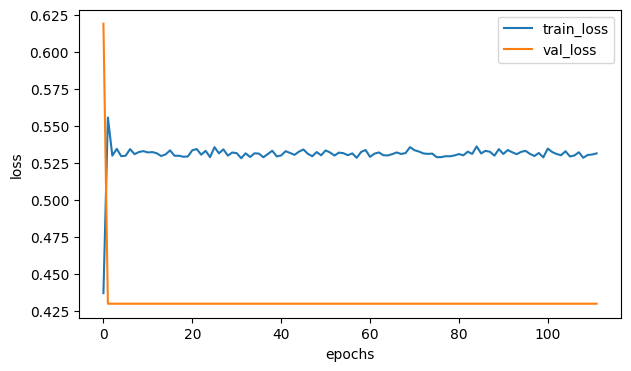


Epoch 113  |  Loss T:0.5332 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 114  |  Loss T:0.5315 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 115  |  Loss T:0.5322 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 116  |  Loss T:0.5288 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 117  |  Loss T:0.5304 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 118  |  Loss T:0.5321 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 119  |  Loss T:0.5312 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 120  |  Loss T:0.5296 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 121  |  Loss T:0.5285 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 122  |  Loss T:0.5322 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 123  |  Loss T:0.5310 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 124  |  Loss T:0.5295 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 125  |  Loss T:0.5289 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 126  |  Loss T:0.5310 V:0.4296  |  Accuracy T:0.3108, V:0.4051

Epoch 127  |  Loss 

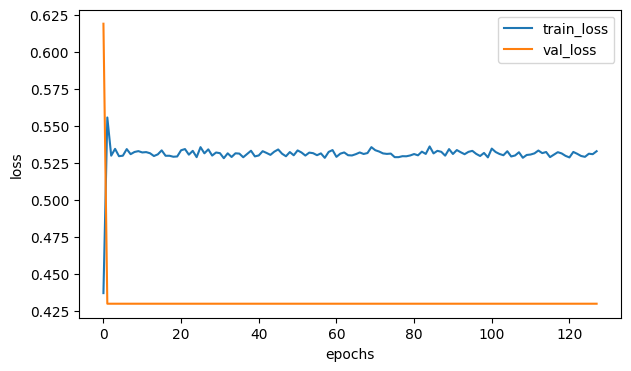

In [73]:
dice_model = SegNet().to(DEVICE)

history_dice = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=dice_model, 
    model_name='dice_model',
    epochs=128, 
    batch_size=8, 
    criterion=dice_loss_torch,
    optimizer=torch.optim.AdamW(dice_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.1163 V:0.1639  |  Accuracy T:0.7973, V:0.6368

Epoch 002  |  Loss T:0.1403 V:0.1249  |  Accuracy T:0.7211, V:0.8128

Epoch 003  |  Loss T:0.1094 V:0.1138  |  Accuracy T:0.8290, V:0.8460

Epoch 004  |  Loss T:0.0876 V:0.1024  |  Accuracy T:0.8736, V:0.8752

Epoch 005  |  Loss T:0.0910 V:0.1260  |  Accuracy T:0.8733, V:0.7746

Epoch 006  |  Loss T:0.0936 V:0.1036  |  Accuracy T:0.8583, V:0.8655

Epoch 007  |  Loss T:0.0917 V:0.0936  |  Accuracy T:0.8662, V:0.8687

Epoch 008  |  Loss T:0.0780 V:0.0842  |  Accuracy T:0.8890, V:0.8972

Epoch 009  |  Loss T:0.0658 V:0.0861  |  Accuracy T:0.9082, V:0.9011

Epoch 010  |  Loss T:0.0590 V:0.0879  |  Accuracy T:0.9203, V:0.8991

Epoch 011  |  Loss T:0.0650 V:0.0901  |  Accuracy T:0.9139, V:0.8991

Epoch 012  |  Loss T:0.0589 V:0.1015  |  Accuracy T:0.9219, V:0.8879

Epoch 013  |  Loss T:0.0580 V:0.0933  |  Accuracy T:0.9208, V:0.9030

Epoch 014  |  Loss T:0.0835 V:0.1020  |  Accuracy T:0.8896, V:0.8649

Epoch 015  |  Loss 

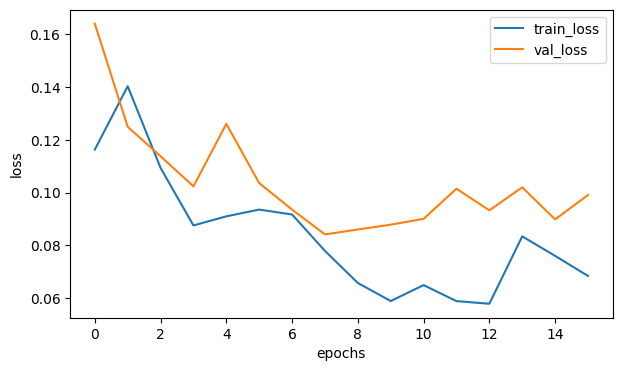


Epoch 017  |  Loss T:0.0561 V:0.0865  |  Accuracy T:0.9187, V:0.9043

Epoch 018  |  Loss T:0.0550 V:0.0811  |  Accuracy T:0.9244, V:0.9014

Epoch 019  |  Loss T:0.0462 V:0.0735  |  Accuracy T:0.9347, V:0.9242

Epoch 020  |  Loss T:0.0433 V:0.0692  |  Accuracy T:0.9380, V:0.9205

Epoch 021  |  Loss T:0.0454 V:0.0711  |  Accuracy T:0.9365, V:0.9280

Epoch 022  |  Loss T:0.0374 V:0.0798  |  Accuracy T:0.9429, V:0.9279

Epoch 023  |  Loss T:0.0332 V:0.0670  |  Accuracy T:0.9507, V:0.9282

Epoch 024  |  Loss T:0.0330 V:0.0617  |  Accuracy T:0.9502, V:0.9286

Epoch 025  |  Loss T:0.0304 V:0.0685  |  Accuracy T:0.9524, V:0.9265

Epoch 026  |  Loss T:0.0315 V:0.0915  |  Accuracy T:0.9513, V:0.9232

Epoch 027  |  Loss T:0.0283 V:0.0764  |  Accuracy T:0.9558, V:0.9285

Epoch 028  |  Loss T:0.0287 V:0.0852  |  Accuracy T:0.9537, V:0.9255

Epoch 029  |  Loss T:0.0288 V:0.0851  |  Accuracy T:0.9553, V:0.9328

Epoch 030  |  Loss T:0.0263 V:0.0723  |  Accuracy T:0.9595, V:0.9339

Epoch 031  |  Loss 

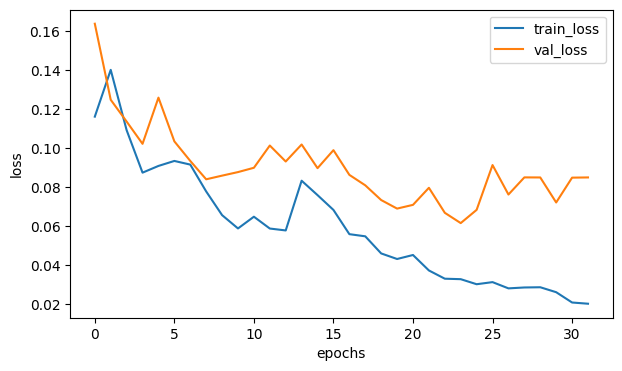


Epoch 033  |  Loss T:0.0183 V:0.0965  |  Accuracy T:0.9701, V:0.9318

Epoch 034  |  Loss T:0.0166 V:0.1418  |  Accuracy T:0.9728, V:0.9205

Epoch 035  |  Loss T:0.0186 V:0.1292  |  Accuracy T:0.9696, V:0.9256

Epoch 036  |  Loss T:0.0240 V:0.0910  |  Accuracy T:0.9643, V:0.9222

Epoch 037  |  Loss T:0.0195 V:0.0904  |  Accuracy T:0.9697, V:0.9308

Epoch 038  |  Loss T:0.0161 V:0.1156  |  Accuracy T:0.9743, V:0.9247

Epoch 039  |  Loss T:0.0152 V:0.1196  |  Accuracy T:0.9760, V:0.9273

Epoch 040  |  Loss T:0.0139 V:0.1399  |  Accuracy T:0.9773, V:0.9216

Epoch 041  |  Loss T:0.0135 V:0.1522  |  Accuracy T:0.9778, V:0.9239

Epoch 042  |  Loss T:0.0119 V:0.1237  |  Accuracy T:0.9805, V:0.9257

Epoch 043  |  Loss T:0.0123 V:0.1355  |  Accuracy T:0.9808, V:0.9267

Epoch 044  |  Loss T:0.0112 V:0.1378  |  Accuracy T:0.9818, V:0.9304

Epoch 045  |  Loss T:0.0103 V:0.1633  |  Accuracy T:0.9836, V:0.9223

Epoch 046  |  Loss T:0.0103 V:0.1580  |  Accuracy T:0.9834, V:0.9230

Epoch 047  |  Loss 

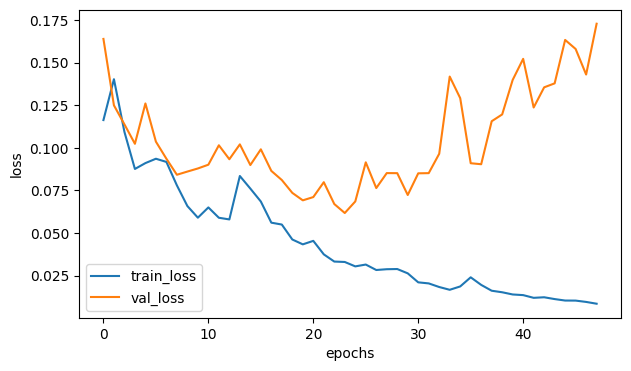


Epoch 049  |  Loss T:0.0081 V:0.1788  |  Accuracy T:0.9869, V:0.9255

Epoch 050  |  Loss T:0.0082 V:0.1764  |  Accuracy T:0.9866, V:0.9243

Epoch 051  |  Loss T:0.0092 V:0.1963  |  Accuracy T:0.9850, V:0.9245

Epoch 052  |  Loss T:0.0089 V:0.1719  |  Accuracy T:0.9856, V:0.9252

Epoch 053  |  Loss T:0.0077 V:0.1851  |  Accuracy T:0.9877, V:0.9269

Epoch 054  |  Loss T:0.0068 V:0.2040  |  Accuracy T:0.9891, V:0.9256

Epoch 055  |  Loss T:0.0062 V:0.2247  |  Accuracy T:0.9900, V:0.9252

Epoch 056  |  Loss T:0.0060 V:0.2158  |  Accuracy T:0.9902, V:0.9271

Epoch 057  |  Loss T:0.0062 V:0.2324  |  Accuracy T:0.9898, V:0.9252

Epoch 058  |  Loss T:0.0062 V:0.2255  |  Accuracy T:0.9899, V:0.9254

Epoch 059  |  Loss T:0.0061 V:0.2296  |  Accuracy T:0.9900, V:0.9257

Epoch 060  |  Loss T:0.0056 V:0.2406  |  Accuracy T:0.9910, V:0.9257

Epoch 061  |  Loss T:0.0051 V:0.2479  |  Accuracy T:0.9918, V:0.9260

Epoch 062  |  Loss T:0.0049 V:0.2578  |  Accuracy T:0.9921, V:0.9247

Epoch 063  |  Loss 

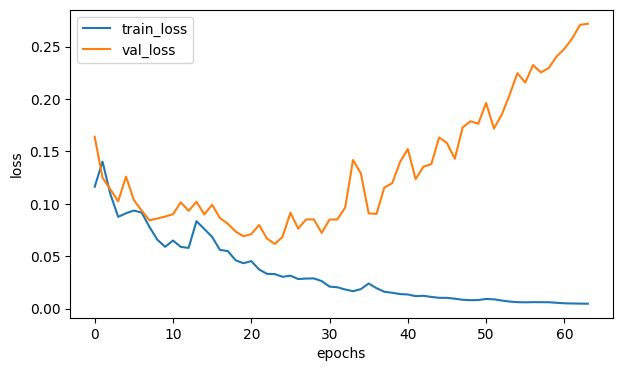


Epoch 065  |  Loss T:0.0049 V:0.2656  |  Accuracy T:0.9920, V:0.9257

Epoch 066  |  Loss T:0.0046 V:0.2756  |  Accuracy T:0.9925, V:0.9268

Epoch 067  |  Loss T:0.0046 V:0.2825  |  Accuracy T:0.9925, V:0.9250

Epoch 068  |  Loss T:0.0045 V:0.2964  |  Accuracy T:0.9926, V:0.9242

Epoch 069  |  Loss T:0.0043 V:0.2835  |  Accuracy T:0.9930, V:0.9243

Epoch 070  |  Loss T:0.0042 V:0.2961  |  Accuracy T:0.9932, V:0.9260

Epoch 071  |  Loss T:0.0041 V:0.2949  |  Accuracy T:0.9934, V:0.9250

Epoch 072  |  Loss T:0.0044 V:0.2977  |  Accuracy T:0.9928, V:0.9255

Epoch 073  |  Loss T:0.0042 V:0.3037  |  Accuracy T:0.9932, V:0.9249

Epoch 074  |  Loss T:0.0038 V:0.3036  |  Accuracy T:0.9938, V:0.9252

Epoch 075  |  Loss T:0.0035 V:0.3336  |  Accuracy T:0.9943, V:0.9252

Epoch 076  |  Loss T:0.0033 V:0.3583  |  Accuracy T:0.9947, V:0.9248

Epoch 077  |  Loss T:0.0033 V:0.3581  |  Accuracy T:0.9947, V:0.9243

Epoch 078  |  Loss T:0.0032 V:0.3642  |  Accuracy T:0.9948, V:0.9250

Epoch 079  |  Loss 

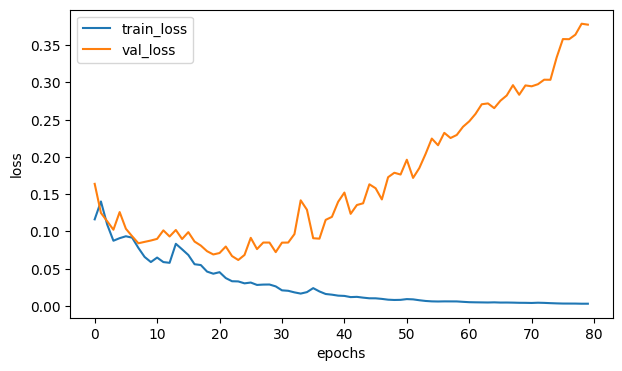


Epoch 081  |  Loss T:0.0032 V:0.3638  |  Accuracy T:0.9948, V:0.9226

Epoch 082  |  Loss T:0.0035 V:0.3473  |  Accuracy T:0.9944, V:0.9246

Epoch 083  |  Loss T:0.0032 V:0.3489  |  Accuracy T:0.9949, V:0.9245

Epoch 084  |  Loss T:0.0030 V:0.3901  |  Accuracy T:0.9951, V:0.9237

Epoch 085  |  Loss T:0.0029 V:0.3882  |  Accuracy T:0.9954, V:0.9251

Epoch 086  |  Loss T:0.0027 V:0.3891  |  Accuracy T:0.9956, V:0.9267

Epoch 087  |  Loss T:0.0026 V:0.4169  |  Accuracy T:0.9958, V:0.9236

Epoch 088  |  Loss T:0.0025 V:0.4203  |  Accuracy T:0.9959, V:0.9251

Epoch 089  |  Loss T:0.0025 V:0.4247  |  Accuracy T:0.9960, V:0.9251

Epoch 090  |  Loss T:0.0026 V:0.4118  |  Accuracy T:0.9957, V:0.9246

Epoch 091  |  Loss T:0.0026 V:0.4085  |  Accuracy T:0.9958, V:0.9257

Epoch 092  |  Loss T:0.0024 V:0.4518  |  Accuracy T:0.9961, V:0.9249

Epoch 093  |  Loss T:0.0025 V:0.4228  |  Accuracy T:0.9959, V:0.9250

Epoch 094  |  Loss T:0.0027 V:0.3960  |  Accuracy T:0.9957, V:0.9257

Epoch 095  |  Loss 

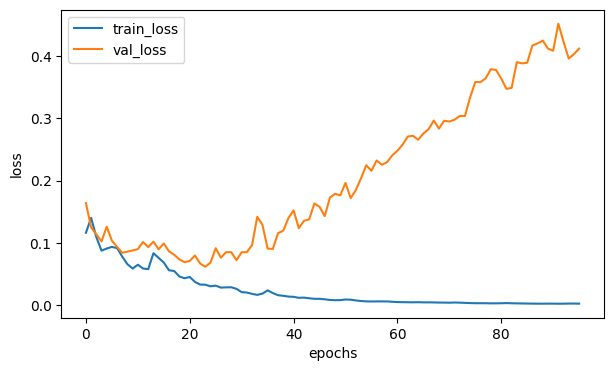


Epoch 097  |  Loss T:0.0026 V:0.4253  |  Accuracy T:0.9957, V:0.9255

Epoch 098  |  Loss T:0.0026 V:0.4035  |  Accuracy T:0.9958, V:0.9255

Epoch 099  |  Loss T:0.0023 V:0.4409  |  Accuracy T:0.9963, V:0.9249

Epoch 100  |  Loss T:0.0022 V:0.4541  |  Accuracy T:0.9964, V:0.9265

Epoch 101  |  Loss T:0.0022 V:0.4755  |  Accuracy T:0.9964, V:0.9240

Epoch 102  |  Loss T:0.0022 V:0.4407  |  Accuracy T:0.9964, V:0.9262

Epoch 103  |  Loss T:0.0022 V:0.4675  |  Accuracy T:0.9964, V:0.9237

Epoch 104  |  Loss T:0.0023 V:0.4292  |  Accuracy T:0.9963, V:0.9250

Epoch 105  |  Loss T:0.0025 V:0.4340  |  Accuracy T:0.9960, V:0.9235

Epoch 106  |  Loss T:0.0024 V:0.4400  |  Accuracy T:0.9961, V:0.9246

Epoch 107  |  Loss T:0.0024 V:0.4572  |  Accuracy T:0.9962, V:0.9253

Epoch 108  |  Loss T:0.0021 V:0.4506  |  Accuracy T:0.9966, V:0.9247

Epoch 109  |  Loss T:0.0020 V:0.4907  |  Accuracy T:0.9968, V:0.9244

Epoch 110  |  Loss T:0.0020 V:0.4865  |  Accuracy T:0.9967, V:0.9252

Epoch 111  |  Loss 

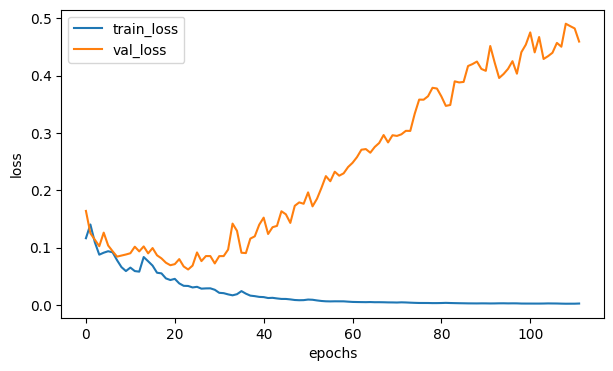


Epoch 113  |  Loss T:0.0026 V:0.4088  |  Accuracy T:0.9959, V:0.9250

Epoch 114  |  Loss T:0.0028 V:0.4174  |  Accuracy T:0.9954, V:0.9240

Epoch 115  |  Loss T:0.0024 V:0.4619  |  Accuracy T:0.9962, V:0.9235

Epoch 116  |  Loss T:0.0021 V:0.4750  |  Accuracy T:0.9966, V:0.9251

Epoch 117  |  Loss T:0.0019 V:0.5294  |  Accuracy T:0.9969, V:0.9238

Epoch 118  |  Loss T:0.0018 V:0.5096  |  Accuracy T:0.9972, V:0.9257

Epoch 119  |  Loss T:0.0018 V:0.5292  |  Accuracy T:0.9970, V:0.9248

Epoch 120  |  Loss T:0.0019 V:0.5408  |  Accuracy T:0.9970, V:0.9245

Epoch 121  |  Loss T:0.0023 V:0.4756  |  Accuracy T:0.9962, V:0.9242

Epoch 122  |  Loss T:0.0026 V:0.4152  |  Accuracy T:0.9958, V:0.9247

Epoch 123  |  Loss T:0.0024 V:0.4331  |  Accuracy T:0.9962, V:0.9257

Epoch 124  |  Loss T:0.0020 V:0.4746  |  Accuracy T:0.9967, V:0.9248

Epoch 125  |  Loss T:0.0017 V:0.5059  |  Accuracy T:0.9974, V:0.9265

Epoch 126  |  Loss T:0.0024 V:0.4760  |  Accuracy T:0.9964, V:0.9232

Epoch 127  |  Loss 

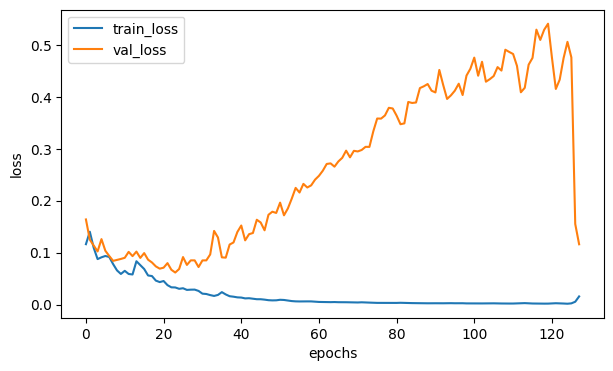

In [61]:
cleanup_models()
focal_model = SegNet().to(DEVICE)

history_focal = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=focal_model, 
    model_name='focal_model',
    epochs=128, 
    batch_size=8, 
    criterion=focal_loss,
    optimizer=torch.optim.AdamW(focal_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss 
)

In [91]:
cleanup_models()
test_model_checkpoint("best_model.pth", model=SegNet, criterion=bce_mean)
cleanup_models()
test_model_checkpoint("best_focal_model.pth", model=SegNet, criterion=focal_loss)
cleanup_models()
test_model_checkpoint("best_dice_model.pth", model=SegNet, criterion=dice_loss_torch)
cleanup_models()

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\2410446969.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)



----- ----- best_model.pth ----- -----
Epoch: 48
Elapsed time: 442.52898931503296 sec.
Test loss: 0.3248785436153412, test accuracy: 0.2930608113606771
Test IoU: 0.6938391923904419

----- ----- best_focal_model.pth ----- -----
Epoch: 23
Elapsed time: 241.57193183898926 sec.
Test loss: 0.0625595971941948, test accuracy: 0.3050740559895833
Test IoU: 0.7848775386810303

----- ----- best_dice_model.pth ----- -----
Epoch: 1
Elapsed time: 19.929376125335693 sec.
Test loss: 0.4980847239494324, test accuracy: 0.11167933146158854
Test IoU: 0.3350380063056946


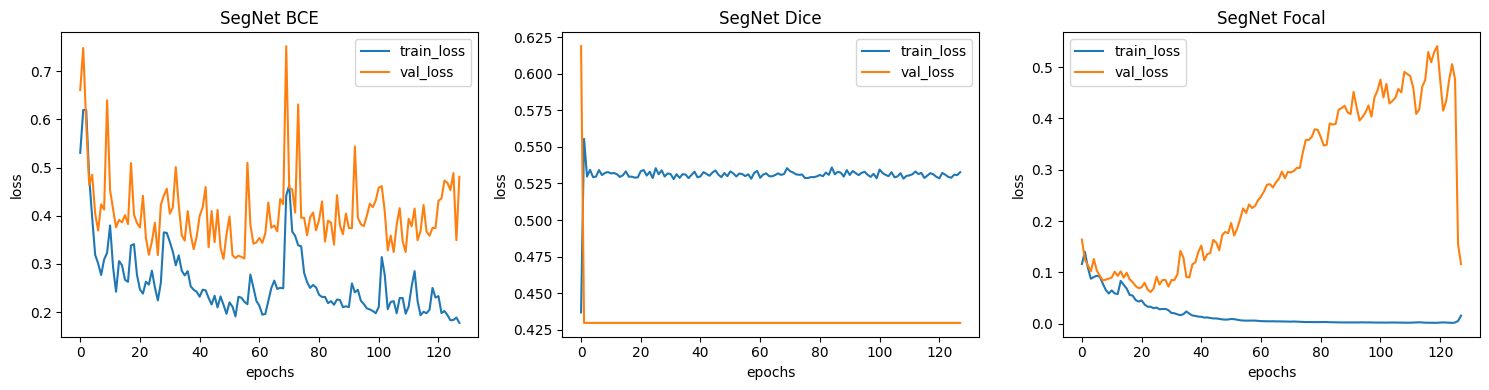

In [90]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

plot_epoch_loss(history, ax=axs[0])
axs[0].set_title("SegNet BCE")
plot_epoch_loss(history_dice, ax=axs[1])
axs[1].set_title("SegNet Dice")
plot_epoch_loss(history_focal, ax=axs[2])
axs[2].set_title("SegNet Focal")

plt.tight_layout()
plt.show()


### Ответы

- Модель сходится быстрее на **focal loss** (23 эпохи), качество неплохое (0.78 IoU)
- На **BCE** сходимость позже и качество на выходе хуже (0.69 IoU)
- На dice вообще всё печально, что моя реализация, что библиотечная - сходимости никакой, пульса нет

---

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

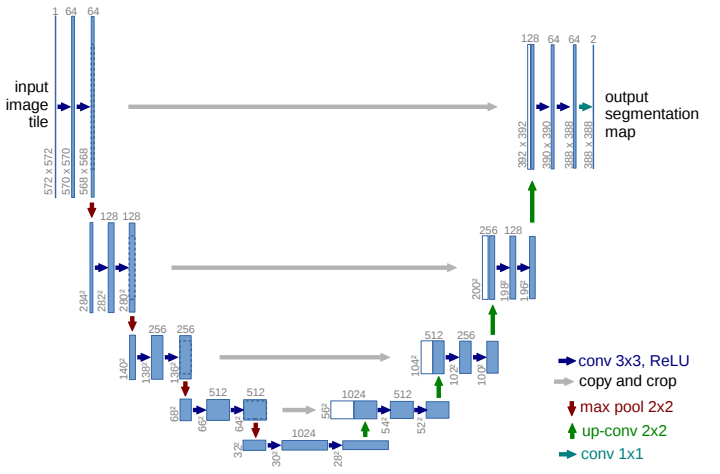

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [63]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

---

Для более честного сравнения архитектур, будем использовать то же количество блоков и слоёв в них

In [64]:
class UEncoderBlock(EncoderBlock):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, bottleneck = False):
        super(UEncoderBlock, self).__init__(in_channels, out_channels, depth, kernel_size, padding)

        if bottleneck:
            self.maxpooling = None

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        
        x_skip = x

        if self.maxpooling is None:
            return x, None, None  # no pooling in bottleneck 

        x, indices = self.maxpooling(x)
        return x, x_skip, indices


class UDecoderBlock(DecoderBlock):

    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True, reduce_channels_at='head'):
        super(UDecoderBlock, self).__init__(in_channels, out_channels, depth, kernel_size, padding, tail_activation, reduce_channels_at) 

    def forward(self, x, x_skip, max_indices):
        x = self.upsampling(x, max_indices)
        x = torch.cat([x, x_skip], dim=1)  # add skip connections

        for layer in self.layers:
            x = layer(x)
        
        return x


class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3, num_features = 64):
        super(UNet, self).__init__()

        self.in_conv = nn.Conv2d(in_channels=in_channels, out_channels=num_features, kernel_size=1)

        self.encoders = nn.ModuleList([
            UEncoderBlock(num_features,     num_features * 2,  depth=2),
            UEncoderBlock(num_features * 2, num_features * 4,  depth=2),
            UEncoderBlock(num_features * 4, num_features * 8,  depth=3),
            UEncoderBlock(num_features * 8, num_features * 16, depth=3),
        ])

        self.bottleneck = UEncoderBlock(num_features * 16, num_features * 16, depth=3, bottleneck=True)

        self.decoders = nn.ModuleList([            
            UDecoderBlock(num_features * (16*2), num_features * 8, depth=3),
            UDecoderBlock(num_features * (8*2),  num_features * 4,  depth=3),
            UDecoderBlock(num_features * (4*2),  num_features * 2,  depth=2),
            UDecoderBlock(num_features * (2*2),  num_features,      depth=2),
        ])

        self.out_conv = nn.Conv2d(in_channels=64, out_channels=n_class, kernel_size=1)


    def forward(self, x):
        x = self.in_conv(x)

        max_pooling_indices = []
        x_skips = []
        for encoder in self.encoders:
            x, x_skip, indices = encoder(x)
            x_skips.append(x_skip)
            max_pooling_indices.append(indices)

        x, _, _ = self.bottleneck(x)

        for decoder, indices, skip in zip(self.decoders, reversed(max_pooling_indices), reversed(x_skips)):
            x = decoder(x, x_skip=skip, max_indices=indices)

        return self.out_conv(x)

---

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



### Обучение UNet

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.3706 V:0.5978  |  Accuracy T:0.8657, V:0.6268

Epoch 002  |  Loss T:0.5232 V:0.6034  |  Accuracy T:0.7478, V:0.6926

Epoch 003  |  Loss T:0.4314 V:0.4558  |  Accuracy T:0.8150, V:0.8262

Epoch 004  |  Loss T:0.4990 V:0.7962  |  Accuracy T:0.7448, V:0.7073

Epoch 005  |  Loss T:0.4661 V:0.4910  |  Accuracy T:0.7844, V:0.8041

Epoch 006  |  Loss T:0.4056 V:0.4347  |  Accuracy T:0.8307, V:0.8325

Epoch 007  |  Loss T:0.3750 V:0.4464  |  Accuracy T:0.8359, V:0.8291

Epoch 008  |  Loss T:0.3645 V:0.4233  |  Accuracy T:0.8447, V:0.8379

Epoch 009  |  Loss T:0.3562 V:0.4440  |  Accuracy T:0.8423, V:0.8385

Epoch 010  |  Loss T:0.3367 V:0.3700  |  Accuracy T:0.8548, V:0.8579

Epoch 011  |  Loss T:0.3283 V:0.3830  |  Accuracy T:0.8596, V:0.8576

Epoch 012  |  Loss T:0.3442 V:0.4859  |  Accuracy T:0.8546, V:0.8274

Epoch 013  |  Loss T:0.3345 V:0.3908  |  Accuracy T:0.8549, V:0.8444

Epoch 014  |  Loss T:0.3255 V:0.3654  |  Accuracy T:0.8599, V:0.8636

Epoch 015  |  Loss 

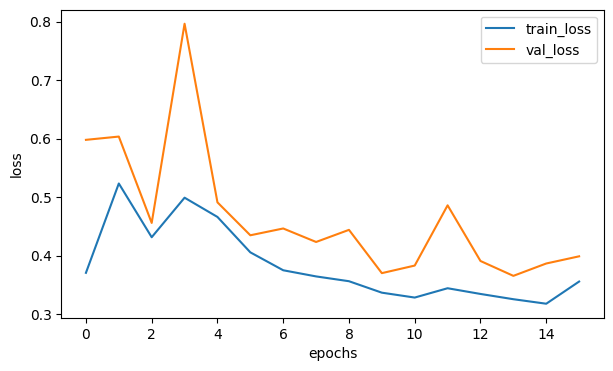


Epoch 017  |  Loss T:0.3210 V:0.5074  |  Accuracy T:0.8702, V:0.8029

Epoch 018  |  Loss T:0.3798 V:0.3542  |  Accuracy T:0.8433, V:0.8605

Epoch 019  |  Loss T:0.3286 V:0.3513  |  Accuracy T:0.8634, V:0.8708

Epoch 020  |  Loss T:0.3157 V:0.3599  |  Accuracy T:0.8742, V:0.8543

Epoch 021  |  Loss T:0.3257 V:0.3975  |  Accuracy T:0.8661, V:0.8490

Epoch 022  |  Loss T:0.3218 V:0.3467  |  Accuracy T:0.8660, V:0.8644

Epoch 023  |  Loss T:0.3159 V:0.3381  |  Accuracy T:0.8707, V:0.8680

Epoch 024  |  Loss T:0.3040 V:0.3315  |  Accuracy T:0.8784, V:0.8626

Epoch 025  |  Loss T:0.3526 V:0.7478  |  Accuracy T:0.8549, V:0.7959

Epoch 026  |  Loss T:0.2968 V:0.3307  |  Accuracy T:0.8772, V:0.8746

Epoch 027  |  Loss T:0.3090 V:0.3427  |  Accuracy T:0.8744, V:0.8567

Epoch 028  |  Loss T:0.2772 V:0.3348  |  Accuracy T:0.8933, V:0.8790

Epoch 029  |  Loss T:0.2418 V:0.2755  |  Accuracy T:0.9066, V:0.8952

Epoch 030  |  Loss T:0.2392 V:0.3049  |  Accuracy T:0.9052, V:0.8817

Epoch 031  |  Loss 

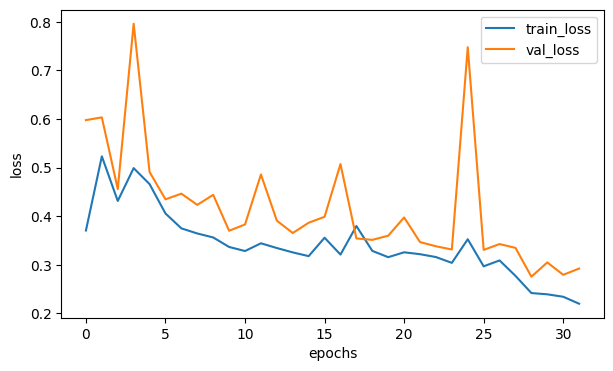


Epoch 033  |  Loss T:0.2197 V:0.2450  |  Accuracy T:0.9145, V:0.9092

Epoch 034  |  Loss T:0.2599 V:0.3038  |  Accuracy T:0.9042, V:0.8786

Epoch 035  |  Loss T:0.2263 V:0.3118  |  Accuracy T:0.9141, V:0.8952

Epoch 036  |  Loss T:0.2076 V:0.3272  |  Accuracy T:0.9233, V:0.8935

Epoch 037  |  Loss T:0.2448 V:0.2570  |  Accuracy T:0.9033, V:0.9017

Epoch 038  |  Loss T:0.2032 V:0.6330  |  Accuracy T:0.9201, V:0.8884

Epoch 039  |  Loss T:0.2375 V:0.2667  |  Accuracy T:0.9189, V:0.9078

Epoch 040  |  Loss T:0.2401 V:0.2564  |  Accuracy T:0.9112, V:0.9054

Epoch 041  |  Loss T:0.2118 V:0.2439  |  Accuracy T:0.9140, V:0.9097

Epoch 042  |  Loss T:0.2074 V:0.2986  |  Accuracy T:0.9200, V:0.9090

Epoch 043  |  Loss T:0.2033 V:0.2465  |  Accuracy T:0.9215, V:0.9148

Epoch 044  |  Loss T:0.1932 V:0.2644  |  Accuracy T:0.9243, V:0.9110

Epoch 045  |  Loss T:0.1897 V:0.2337  |  Accuracy T:0.9273, V:0.9134

Epoch 046  |  Loss T:0.1952 V:0.2680  |  Accuracy T:0.9233, V:0.9076

Epoch 047  |  Loss 

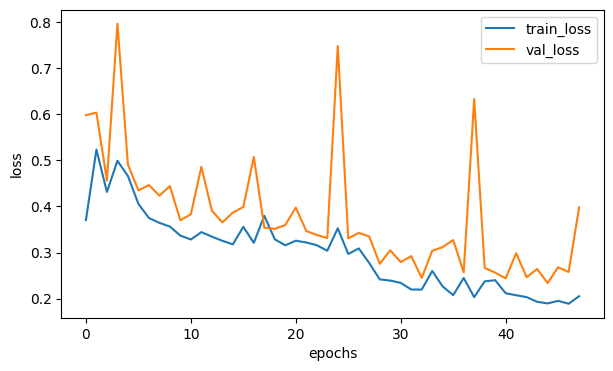


Epoch 049  |  Loss T:0.2182 V:0.3166  |  Accuracy T:0.9163, V:0.8858

Epoch 050  |  Loss T:0.2100 V:0.2639  |  Accuracy T:0.9207, V:0.9065

Epoch 051  |  Loss T:0.2187 V:0.3947  |  Accuracy T:0.9167, V:0.8872

Epoch 052  |  Loss T:0.2070 V:0.2960  |  Accuracy T:0.9241, V:0.9103

Epoch 053  |  Loss T:0.2148 V:0.2583  |  Accuracy T:0.9208, V:0.9192

Epoch 054  |  Loss T:0.1780 V:0.2651  |  Accuracy T:0.9304, V:0.9131

Epoch 055  |  Loss T:0.1710 V:0.2637  |  Accuracy T:0.9325, V:0.9079

Epoch 056  |  Loss T:0.1942 V:0.2628  |  Accuracy T:0.9266, V:0.9002

Epoch 057  |  Loss T:0.1819 V:0.2383  |  Accuracy T:0.9309, V:0.9213

Epoch 058  |  Loss T:0.1823 V:0.2238  |  Accuracy T:0.9308, V:0.9252

Epoch 059  |  Loss T:0.1651 V:0.2633  |  Accuracy T:0.9341, V:0.9219

Epoch 060  |  Loss T:0.1656 V:0.2736  |  Accuracy T:0.9349, V:0.9234

Epoch 061  |  Loss T:0.1595 V:0.2156  |  Accuracy T:0.9386, V:0.9112

Epoch 062  |  Loss T:0.1628 V:0.2510  |  Accuracy T:0.9358, V:0.9321

Epoch 063  |  Loss 

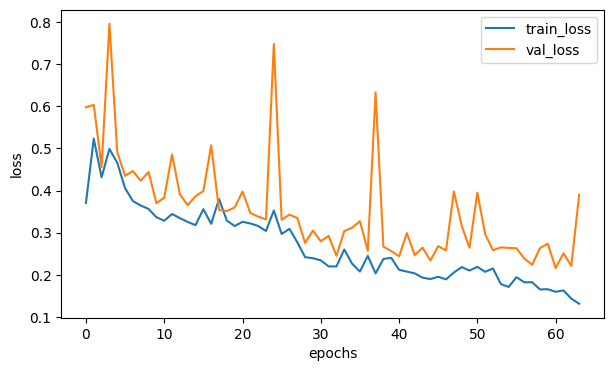


Epoch 065  |  Loss T:0.1393 V:0.3051  |  Accuracy T:0.9477, V:0.9092

Epoch 066  |  Loss T:0.1847 V:0.2976  |  Accuracy T:0.9276, V:0.8920

Epoch 067  |  Loss T:0.2305 V:0.2058  |  Accuracy T:0.9163, V:0.9286

Epoch 068  |  Loss T:0.1584 V:0.2014  |  Accuracy T:0.9387, V:0.9338

Epoch 069  |  Loss T:0.1337 V:0.2361  |  Accuracy T:0.9476, V:0.9279

Epoch 070  |  Loss T:0.1329 V:0.2342  |  Accuracy T:0.9468, V:0.9288

Epoch 071  |  Loss T:0.1133 V:0.2268  |  Accuracy T:0.9544, V:0.9355

Epoch 072  |  Loss T:0.1284 V:0.2240  |  Accuracy T:0.9488, V:0.9278

Epoch 073  |  Loss T:0.1119 V:0.2027  |  Accuracy T:0.9557, V:0.9363

Epoch 074  |  Loss T:0.1070 V:0.2154  |  Accuracy T:0.9569, V:0.9379

Epoch 075  |  Loss T:0.0988 V:0.2241  |  Accuracy T:0.9590, V:0.9349

Epoch 076  |  Loss T:0.1004 V:0.2881  |  Accuracy T:0.9598, V:0.9327

Epoch 077  |  Loss T:0.0949 V:0.2773  |  Accuracy T:0.9615, V:0.9343

Epoch 078  |  Loss T:0.0900 V:0.2646  |  Accuracy T:0.9634, V:0.9362

Epoch 079  |  Loss 

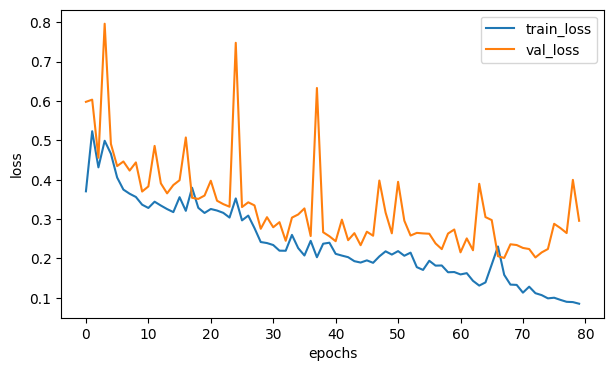


Epoch 081  |  Loss T:0.1061 V:0.2155  |  Accuracy T:0.9578, V:0.9309

Epoch 082  |  Loss T:0.0995 V:0.2319  |  Accuracy T:0.9603, V:0.9403

Epoch 083  |  Loss T:0.0846 V:0.2839  |  Accuracy T:0.9652, V:0.9348

Epoch 084  |  Loss T:0.0802 V:0.2494  |  Accuracy T:0.9673, V:0.9355

Epoch 085  |  Loss T:0.0805 V:0.2369  |  Accuracy T:0.9663, V:0.9378

Epoch 086  |  Loss T:0.0933 V:0.2608  |  Accuracy T:0.9610, V:0.9326

Epoch 087  |  Loss T:0.0794 V:0.2307  |  Accuracy T:0.9667, V:0.9390

Epoch 088  |  Loss T:0.0688 V:0.2899  |  Accuracy T:0.9713, V:0.9379

Epoch 089  |  Loss T:0.0625 V:0.2725  |  Accuracy T:0.9737, V:0.9405

Epoch 090  |  Loss T:0.0612 V:0.3555  |  Accuracy T:0.9743, V:0.9372

Epoch 091  |  Loss T:0.0578 V:0.3142  |  Accuracy T:0.9758, V:0.9373

Epoch 092  |  Loss T:0.0563 V:0.3062  |  Accuracy T:0.9764, V:0.9402

Epoch 093  |  Loss T:0.0559 V:0.3822  |  Accuracy T:0.9765, V:0.9368

Epoch 094  |  Loss T:0.0547 V:0.3667  |  Accuracy T:0.9769, V:0.9400

Epoch 095  |  Loss 

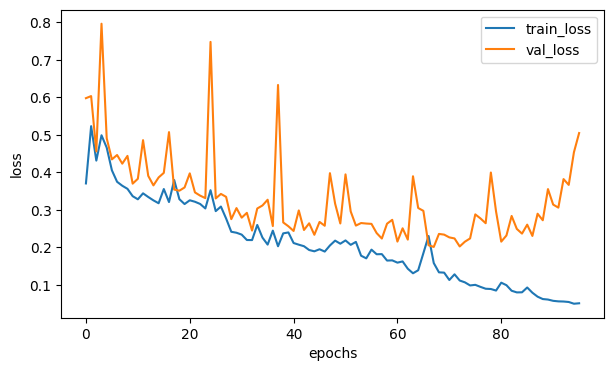


Epoch 097  |  Loss T:0.0507 V:0.4199  |  Accuracy T:0.9788, V:0.9388

Epoch 098  |  Loss T:0.0505 V:0.3432  |  Accuracy T:0.9789, V:0.9439

Epoch 099  |  Loss T:0.1141 V:0.3421  |  Accuracy T:0.9556, V:0.8881

Epoch 100  |  Loss T:0.1939 V:0.2577  |  Accuracy T:0.9285, V:0.9184

Epoch 101  |  Loss T:0.1718 V:0.2233  |  Accuracy T:0.9415, V:0.9266

Epoch 102  |  Loss T:0.1418 V:0.2280  |  Accuracy T:0.9484, V:0.9295

Epoch 103  |  Loss T:0.1283 V:0.2339  |  Accuracy T:0.9492, V:0.9328

Epoch 104  |  Loss T:0.1033 V:0.2817  |  Accuracy T:0.9590, V:0.9260

Epoch 105  |  Loss T:0.0974 V:0.1985  |  Accuracy T:0.9622, V:0.9342

Epoch 106  |  Loss T:0.0920 V:0.2546  |  Accuracy T:0.9636, V:0.9294

Epoch 107  |  Loss T:0.1029 V:0.3409  |  Accuracy T:0.9576, V:0.9256

Epoch 108  |  Loss T:0.0935 V:0.2846  |  Accuracy T:0.9619, V:0.9313

Epoch 109  |  Loss T:0.0817 V:0.2608  |  Accuracy T:0.9667, V:0.9365

Epoch 110  |  Loss T:0.0737 V:0.4653  |  Accuracy T:0.9698, V:0.9337

Epoch 111  |  Loss 

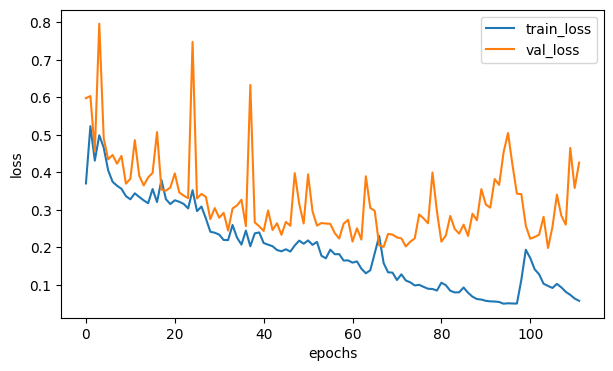


Epoch 113  |  Loss T:0.0521 V:0.4855  |  Accuracy T:0.9781, V:0.9332

Epoch 114  |  Loss T:0.0522 V:0.7356  |  Accuracy T:0.9782, V:0.9317

Epoch 115  |  Loss T:0.0498 V:0.6964  |  Accuracy T:0.9790, V:0.9336

Epoch 116  |  Loss T:0.0454 V:0.6399  |  Accuracy T:0.9808, V:0.9361

Epoch 117  |  Loss T:0.0414 V:0.8459  |  Accuracy T:0.9827, V:0.9337

Epoch 118  |  Loss T:0.0388 V:0.8883  |  Accuracy T:0.9835, V:0.9356

Epoch 119  |  Loss T:0.0370 V:1.0130  |  Accuracy T:0.9843, V:0.9351

Epoch 120  |  Loss T:0.0347 V:0.9662  |  Accuracy T:0.9855, V:0.9346

Epoch 121  |  Loss T:0.0342 V:0.9664  |  Accuracy T:0.9856, V:0.9360

Epoch 122  |  Loss T:0.0319 V:1.2116  |  Accuracy T:0.9866, V:0.9329

Epoch 123  |  Loss T:0.0320 V:1.1730  |  Accuracy T:0.9864, V:0.9344

Epoch 124  |  Loss T:0.0299 V:1.1799  |  Accuracy T:0.9873, V:0.9346

Epoch 125  |  Loss T:0.0305 V:1.3980  |  Accuracy T:0.9871, V:0.9337

Epoch 126  |  Loss T:0.0287 V:1.2146  |  Accuracy T:0.9879, V:0.9347

Epoch 127  |  Loss 

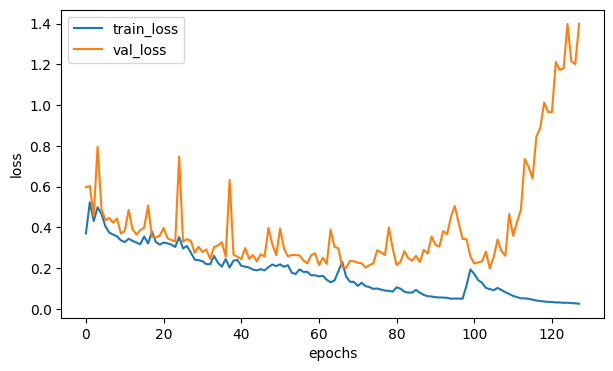

In [65]:
cleanup_models()
unet_model_bce = UNet().to(DEVICE)

bce_mean = nn.BCEWithLogitsLoss(reduction='mean')

history_unet_bce = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_bce, 
    model_name='unet_model_bce',
    epochs=128, 
    batch_size=8, 
    criterion=bce_mean,
    optimizer=torch.optim.AdamW(unet_model_bce.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.3503 V:0.9086  |  Accuracy T:0.8163, V:0.5999

Epoch 002  |  Loss T:0.3695 V:0.1838  |  Accuracy T:0.7478, V:0.8722

Epoch 003  |  Loss T:0.1709 V:0.1735  |  Accuracy T:0.8925, V:0.8945

Epoch 004  |  Loss T:0.1479 V:0.2030  |  Accuracy T:0.9048, V:0.8683

Epoch 005  |  Loss T:0.1296 V:0.1802  |  Accuracy T:0.9202, V:0.8973

Epoch 006  |  Loss T:0.1285 V:0.1504  |  Accuracy T:0.9219, V:0.9036

Epoch 007  |  Loss T:0.1532 V:0.1957  |  Accuracy T:0.9029, V:0.8770

Epoch 008  |  Loss T:0.1981 V:0.3577  |  Accuracy T:0.8533, V:0.7984

Epoch 009  |  Loss T:0.7652 V:0.9797  |  Accuracy T:0.7269, V:0.5985

Epoch 010  |  Loss T:0.9989 V:1.0000  |  Accuracy T:0.6894, V:0.5949

Epoch 011  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6892, V:0.5949

Epoch 012  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6892, V:0.5949

Epoch 013  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6892, V:0.5949

Epoch 014  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6892, V:0.5949

Epoch 015  |  Loss 

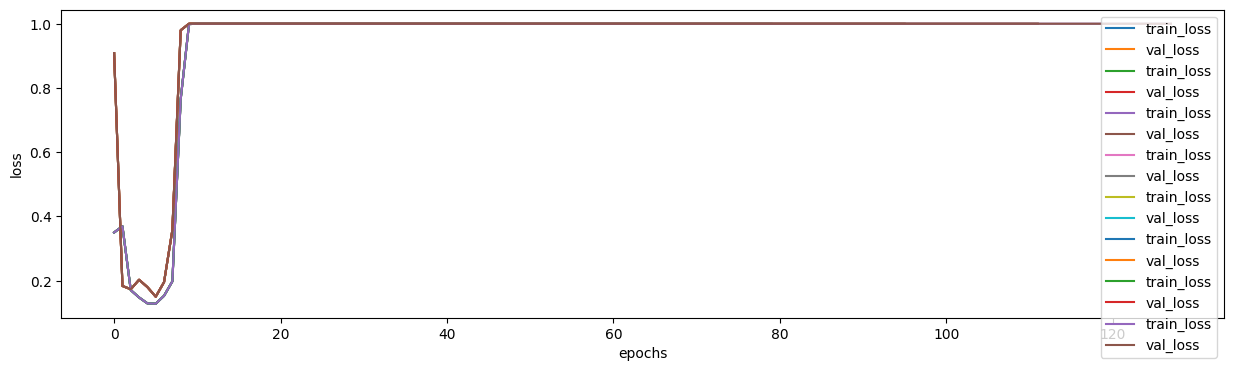

In [80]:
cleanup_models()
unet_model_dice = UNet().to(DEVICE)

history_unet_dice = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_dice, 
    model_name='unet_model_dice',
    epochs=128, 
    batch_size=8, 
    criterion=dice_loss_torch,
    optimizer=torch.optim.AdamW(unet_model_dice.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.0921 V:0.1481  |  Accuracy T:0.8490, V:0.6741

Epoch 002  |  Loss T:0.4329 V:0.1560  |  Accuracy T:0.7285, V:0.7789

Epoch 003  |  Loss T:0.1337 V:0.1976  |  Accuracy T:0.7682, V:0.7058

Epoch 004  |  Loss T:0.1129 V:0.1454  |  Accuracy T:0.7992, V:0.7926

Epoch 005  |  Loss T:0.1058 V:0.1315  |  Accuracy T:0.8230, V:0.8084

Epoch 006  |  Loss T:0.1009 V:0.1142  |  Accuracy T:0.8312, V:0.8355

Epoch 007  |  Loss T:0.1032 V:0.1229  |  Accuracy T:0.8255, V:0.8280

Epoch 008  |  Loss T:0.0987 V:0.1015  |  Accuracy T:0.8289, V:0.8667

Epoch 009  |  Loss T:0.2340 V:0.1297  |  Accuracy T:0.7635, V:0.8205

Epoch 010  |  Loss T:0.1071 V:0.1254  |  Accuracy T:0.8202, V:0.8432

Epoch 011  |  Loss T:0.1017 V:0.1109  |  Accuracy T:0.8216, V:0.8415

Epoch 012  |  Loss T:0.1016 V:0.0994  |  Accuracy T:0.8240, V:0.8481

Epoch 013  |  Loss T:0.0942 V:0.1336  |  Accuracy T:0.8449, V:0.7533

Epoch 014  |  Loss T:0.1052 V:0.1012  |  Accuracy T:0.8009, V:0.8456

Epoch 015  |  Loss 

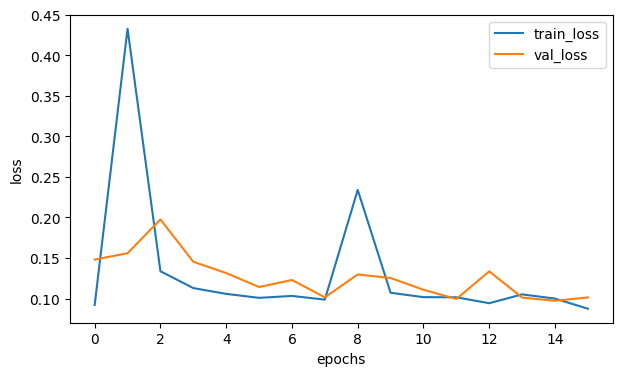


Epoch 017  |  Loss T:0.0926 V:0.0926  |  Accuracy T:0.8442, V:0.8697

Epoch 018  |  Loss T:0.0892 V:0.1039  |  Accuracy T:0.8536, V:0.8433

Epoch 019  |  Loss T:0.0954 V:0.1067  |  Accuracy T:0.8396, V:0.8462

Epoch 020  |  Loss T:0.0894 V:0.0909  |  Accuracy T:0.8580, V:0.8689

Epoch 021  |  Loss T:0.0871 V:0.0896  |  Accuracy T:0.8536, V:0.8725

Epoch 022  |  Loss T:0.0823 V:0.0926  |  Accuracy T:0.8654, V:0.8653

Epoch 023  |  Loss T:0.0907 V:0.0887  |  Accuracy T:0.8521, V:0.8665

Epoch 024  |  Loss T:0.0859 V:0.0900  |  Accuracy T:0.8544, V:0.8708

Epoch 025  |  Loss T:0.0815 V:0.0886  |  Accuracy T:0.8659, V:0.8666

Epoch 026  |  Loss T:0.0902 V:0.1544  |  Accuracy T:0.8456, V:0.7198

Epoch 027  |  Loss T:0.0971 V:0.1239  |  Accuracy T:0.8317, V:0.8200

Epoch 028  |  Loss T:0.0844 V:0.1070  |  Accuracy T:0.8629, V:0.8200

Epoch 029  |  Loss T:0.0846 V:0.0905  |  Accuracy T:0.8626, V:0.8652

Epoch 030  |  Loss T:0.0825 V:0.0959  |  Accuracy T:0.8660, V:0.8591

Epoch 031  |  Loss 

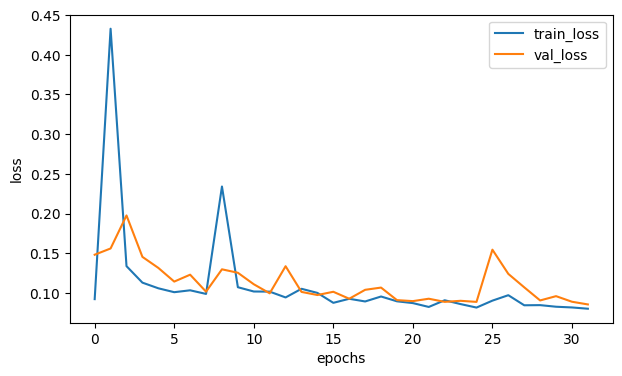


Epoch 033  |  Loss T:0.0861 V:0.0918  |  Accuracy T:0.8544, V:0.8551

Epoch 034  |  Loss T:0.0828 V:0.0871  |  Accuracy T:0.8600, V:0.8642

Epoch 035  |  Loss T:0.0798 V:0.0848  |  Accuracy T:0.8726, V:0.8706

Epoch 036  |  Loss T:0.0857 V:0.0911  |  Accuracy T:0.8549, V:0.8620

Epoch 037  |  Loss T:0.0819 V:0.0907  |  Accuracy T:0.8743, V:0.8637

Epoch 038  |  Loss T:0.0834 V:0.0954  |  Accuracy T:0.8671, V:0.8514

Epoch 039  |  Loss T:0.0849 V:0.0852  |  Accuracy T:0.8600, V:0.8678

Epoch 040  |  Loss T:0.0801 V:0.0943  |  Accuracy T:0.8660, V:0.8615

Epoch 041  |  Loss T:0.0810 V:0.0932  |  Accuracy T:0.8691, V:0.8614

Epoch 042  |  Loss T:0.0795 V:0.0959  |  Accuracy T:0.8696, V:0.8301

Epoch 043  |  Loss T:0.0803 V:0.0862  |  Accuracy T:0.8644, V:0.8647

Epoch 044  |  Loss T:0.0834 V:0.1229  |  Accuracy T:0.8603, V:0.7989

Epoch 045  |  Loss T:0.0977 V:0.0949  |  Accuracy T:0.8374, V:0.8558

Epoch 046  |  Loss T:0.0890 V:0.0886  |  Accuracy T:0.8592, V:0.8679

Epoch 047  |  Loss 

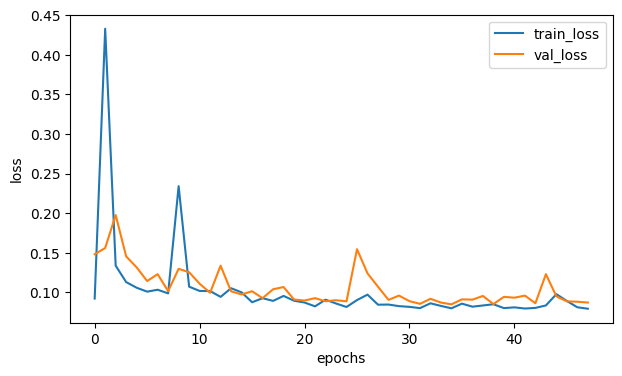


Epoch 049  |  Loss T:0.0777 V:0.0840  |  Accuracy T:0.8747, V:0.8697

Epoch 050  |  Loss T:0.0784 V:0.0890  |  Accuracy T:0.8719, V:0.8673

Epoch 051  |  Loss T:0.0807 V:0.1040  |  Accuracy T:0.8646, V:0.8548

Epoch 052  |  Loss T:0.0819 V:0.0828  |  Accuracy T:0.8646, V:0.8694

Epoch 053  |  Loss T:0.0755 V:0.0890  |  Accuracy T:0.8770, V:0.8619

Epoch 054  |  Loss T:0.0807 V:0.0882  |  Accuracy T:0.8615, V:0.8532

Epoch 055  |  Loss T:0.0816 V:0.0830  |  Accuracy T:0.8662, V:0.8707

Epoch 056  |  Loss T:0.0765 V:0.0848  |  Accuracy T:0.8739, V:0.8631

Epoch 057  |  Loss T:0.0761 V:0.0864  |  Accuracy T:0.8771, V:0.8724

Epoch 058  |  Loss T:0.0796 V:0.0930  |  Accuracy T:0.8701, V:0.8565

Epoch 059  |  Loss T:0.0747 V:0.0802  |  Accuracy T:0.8835, V:0.8855

Epoch 060  |  Loss T:0.0965 V:0.0868  |  Accuracy T:0.8462, V:0.8602

Epoch 061  |  Loss T:0.0800 V:0.0862  |  Accuracy T:0.8742, V:0.8648

Epoch 062  |  Loss T:0.0785 V:0.0835  |  Accuracy T:0.8813, V:0.8710

Epoch 063  |  Loss 

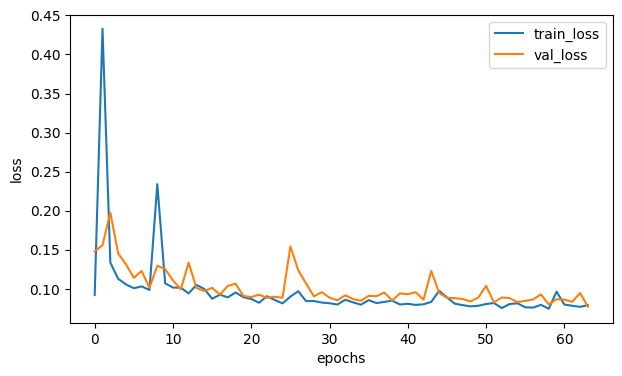


Epoch 065  |  Loss T:0.0840 V:0.0802  |  Accuracy T:0.8715, V:0.8682

Epoch 066  |  Loss T:0.0743 V:0.0716  |  Accuracy T:0.8889, V:0.8872

Epoch 067  |  Loss T:0.0776 V:0.0850  |  Accuracy T:0.8760, V:0.8763

Epoch 068  |  Loss T:0.0797 V:0.0874  |  Accuracy T:0.8720, V:0.8615

Epoch 069  |  Loss T:0.0783 V:0.0814  |  Accuracy T:0.8726, V:0.8726

Epoch 070  |  Loss T:0.0756 V:0.0897  |  Accuracy T:0.8856, V:0.8705

Epoch 071  |  Loss T:0.0732 V:0.0742  |  Accuracy T:0.8965, V:0.8792

Epoch 072  |  Loss T:0.0753 V:0.0757  |  Accuracy T:0.8896, V:0.8896

Epoch 073  |  Loss T:0.0713 V:0.0873  |  Accuracy T:0.8981, V:0.8904

Epoch 074  |  Loss T:0.0631 V:0.0734  |  Accuracy T:0.9091, V:0.8986

Epoch 075  |  Loss T:0.0761 V:0.0785  |  Accuracy T:0.8957, V:0.8820

Epoch 076  |  Loss T:0.0670 V:0.0700  |  Accuracy T:0.9050, V:0.8890

Epoch 077  |  Loss T:0.0631 V:0.0722  |  Accuracy T:0.9060, V:0.8915

Epoch 078  |  Loss T:0.0614 V:0.0682  |  Accuracy T:0.9116, V:0.8826

Epoch 079  |  Loss 

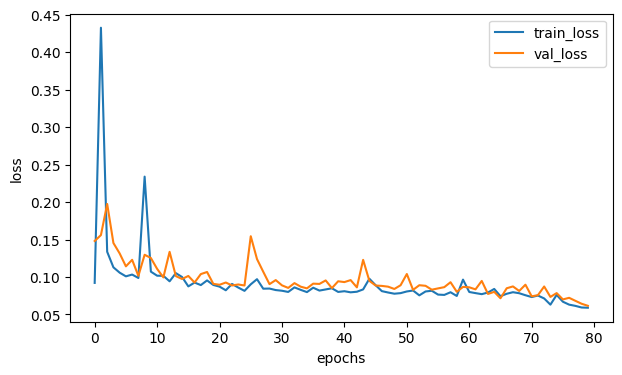


Epoch 081  |  Loss T:0.0609 V:0.0943  |  Accuracy T:0.9126, V:0.8644

Epoch 082  |  Loss T:0.0600 V:0.0735  |  Accuracy T:0.9150, V:0.8981

Epoch 083  |  Loss T:0.0579 V:0.0723  |  Accuracy T:0.9198, V:0.8954

Epoch 084  |  Loss T:0.0569 V:0.0720  |  Accuracy T:0.9156, V:0.8896

Epoch 085  |  Loss T:0.0532 V:0.0649  |  Accuracy T:0.9227, V:0.9025

Epoch 086  |  Loss T:0.0549 V:0.0728  |  Accuracy T:0.9216, V:0.9005

Epoch 087  |  Loss T:0.0573 V:0.0722  |  Accuracy T:0.9189, V:0.8965

Epoch 088  |  Loss T:0.0587 V:0.0726  |  Accuracy T:0.9174, V:0.8989

Epoch 089  |  Loss T:0.0578 V:0.0635  |  Accuracy T:0.9169, V:0.9092

Epoch 090  |  Loss T:0.0557 V:0.0635  |  Accuracy T:0.9231, V:0.9094

Epoch 091  |  Loss T:0.0527 V:0.0776  |  Accuracy T:0.9240, V:0.8839

Epoch 092  |  Loss T:0.0536 V:0.0631  |  Accuracy T:0.9242, V:0.9145

Epoch 093  |  Loss T:0.0552 V:0.0668  |  Accuracy T:0.9183, V:0.9108

Epoch 094  |  Loss T:0.0529 V:0.0617  |  Accuracy T:0.9249, V:0.9101

Epoch 095  |  Loss 

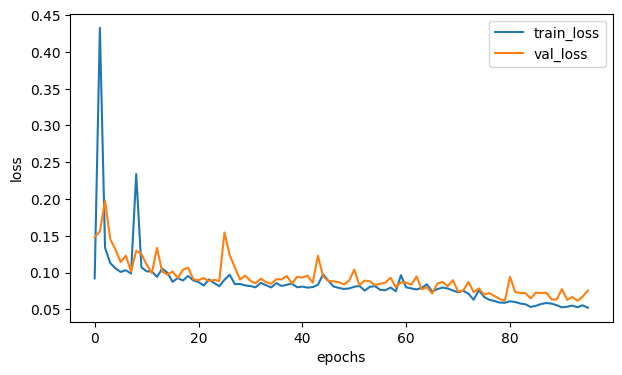


Epoch 097  |  Loss T:0.0490 V:0.0840  |  Accuracy T:0.9279, V:0.9043

Epoch 098  |  Loss T:0.0505 V:0.0593  |  Accuracy T:0.9280, V:0.9180

Epoch 099  |  Loss T:0.0560 V:0.0773  |  Accuracy T:0.9217, V:0.9013

Epoch 100  |  Loss T:0.0529 V:0.0753  |  Accuracy T:0.9258, V:0.9076

Epoch 101  |  Loss T:0.0504 V:0.0747  |  Accuracy T:0.9254, V:0.9133

Epoch 102  |  Loss T:0.0519 V:0.0679  |  Accuracy T:0.9295, V:0.9135

Epoch 103  |  Loss T:0.0495 V:0.0627  |  Accuracy T:0.9298, V:0.9164

Epoch 104  |  Loss T:0.0461 V:0.0639  |  Accuracy T:0.9340, V:0.9096

Epoch 105  |  Loss T:0.0449 V:0.0651  |  Accuracy T:0.9351, V:0.9158

Epoch 106  |  Loss T:0.0413 V:0.0715  |  Accuracy T:0.9397, V:0.9205

Epoch 107  |  Loss T:0.0490 V:0.0588  |  Accuracy T:0.9276, V:0.9219

Epoch 108  |  Loss T:0.0457 V:0.0632  |  Accuracy T:0.9359, V:0.9172

Epoch 109  |  Loss T:0.0442 V:0.0637  |  Accuracy T:0.9351, V:0.9220

Epoch 110  |  Loss T:0.0462 V:0.0581  |  Accuracy T:0.9351, V:0.9274

Epoch 111  |  Loss 

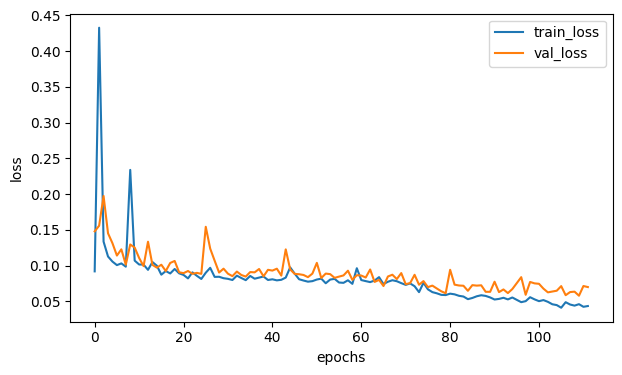


Epoch 113  |  Loss T:0.0403 V:0.0648  |  Accuracy T:0.9415, V:0.9220

Epoch 114  |  Loss T:0.0403 V:0.0728  |  Accuracy T:0.9409, V:0.9252

Epoch 115  |  Loss T:0.0392 V:0.0600  |  Accuracy T:0.9442, V:0.9229

Epoch 116  |  Loss T:0.0396 V:0.0610  |  Accuracy T:0.9432, V:0.9286

Epoch 117  |  Loss T:0.0394 V:0.0621  |  Accuracy T:0.9410, V:0.9301

Epoch 118  |  Loss T:0.0410 V:0.0519  |  Accuracy T:0.9400, V:0.9308

Epoch 119  |  Loss T:0.0384 V:0.0604  |  Accuracy T:0.9438, V:0.9214

Epoch 120  |  Loss T:0.0427 V:0.0636  |  Accuracy T:0.9387, V:0.9243

Epoch 121  |  Loss T:0.0356 V:0.0582  |  Accuracy T:0.9473, V:0.9294

Epoch 122  |  Loss T:0.0343 V:0.0695  |  Accuracy T:0.9490, V:0.9280

Epoch 123  |  Loss T:0.0326 V:0.0723  |  Accuracy T:0.9509, V:0.9302

Epoch 124  |  Loss T:0.0326 V:0.0829  |  Accuracy T:0.9520, V:0.9254

Epoch 125  |  Loss T:0.0355 V:0.0626  |  Accuracy T:0.9468, V:0.9265

Epoch 126  |  Loss T:0.0335 V:0.0633  |  Accuracy T:0.9516, V:0.9178

Epoch 127  |  Loss 

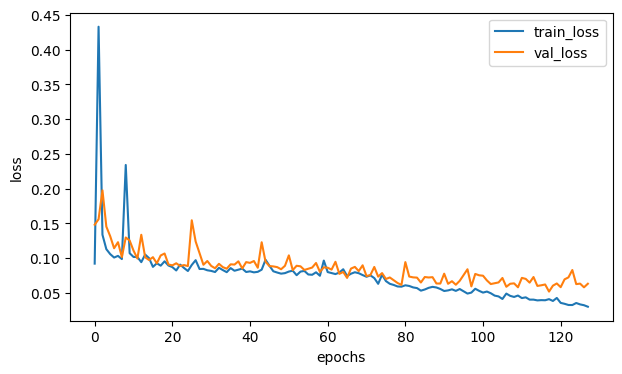

In [67]:
cleanup_models()
unet_model_focal = UNet().to(DEVICE)

history_unet_focal = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_focal, 
    model_name='unet_model_focal',
    epochs=128, 
    batch_size=8, 
    criterion=focal_loss,
    optimizer=torch.optim.AdamW(unet_model_focal.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

### Динамика обучения UNet

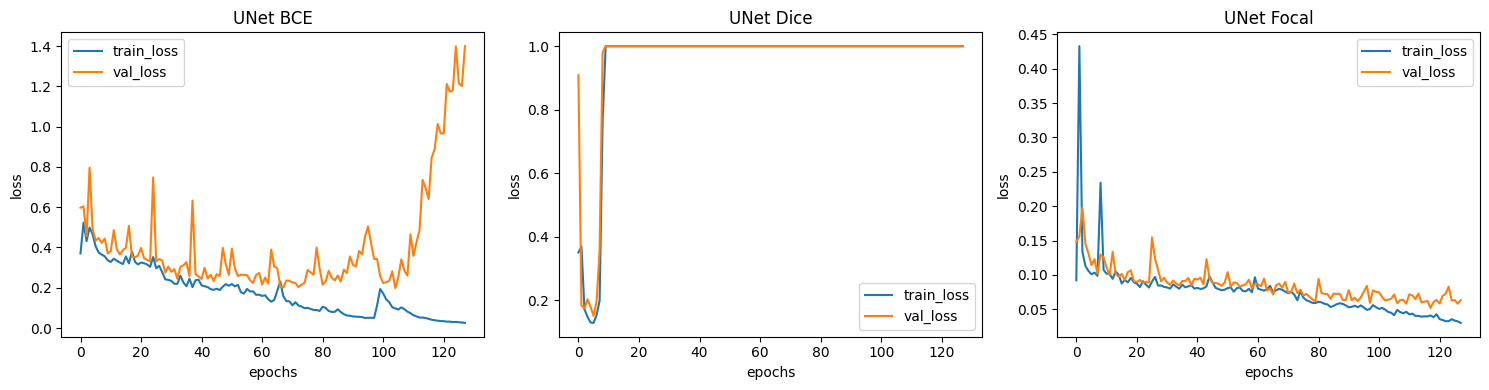

In [82]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

plot_epoch_loss(history_unet_bce, ax=axs[0])
axs[0].set_title("UNet BCE")
plot_epoch_loss(history_unet_dice, ax=axs[1])
axs[1].set_title("UNet Dice")
plot_epoch_loss(history_unet_focal, ax=axs[2])
axs[2].set_title("UNet Focal")

plt.tight_layout()
plt.show()


### Сравнение результатов по UNet

In [71]:
cleanup_models()
test_model_checkpoint("best_unet_model_bce.pth", model=UNet, criterion=bce_mean)
cleanup_models()
test_model_checkpoint("best_unet_model_dice.pth", model=UNet, criterion=bce_mean)
cleanup_models()
test_model_checkpoint("best_unet_model_focal.pth", model=UNet, criterion=bce_mean)
cleanup_models()

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\2410446969.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)



----- ----- best_unet_model_bce.pth ----- -----
Epoch: 104
Elapsed time: 2147.5612046718597 sec.
Test loss: 0.22860026359558105, test accuracy: 0.3029652913411458
Test IoU: 0.7736415863037109

----- ----- best_unet_model_dice.pth ----- -----
Epoch: 7
Elapsed time: 155.03564953804016 sec.
Test loss: 19.11213493347168, test accuracy: 0.23392359415690103
Test IoU: 0.4711539149284363

----- ----- best_unet_model_focal.pth ----- -----
Epoch: 117
Elapsed time: 2388.9947769641876 sec.
Test loss: 0.3346122205257416, test accuracy: 0.30395762125651044
Test IoU: 0.7742486000061035


- Лучшая по метрике IoU модель - **UNet Focal,** Test IoU: 0.7742. Впрочем, у **BCE** результат практически такой же.
- Лучшая по лоссу модель - **UNet BCE,** хотя лоссы разные и их не стоит сравнивать в лоб
- И BCE, и Focal loss - сошлись за 100+ эпох, примерно за одинаковое время, **BCE** чуть быстрее - за 36 минут. 
- Dice loss вообще не сошёлся и с ним всё плохо

### Визуальное сравнение результатов SegNet и UNet

C:\Users\Efim Plotnikov\AppData\Local\Temp\ipykernel_73048\4069067995.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)


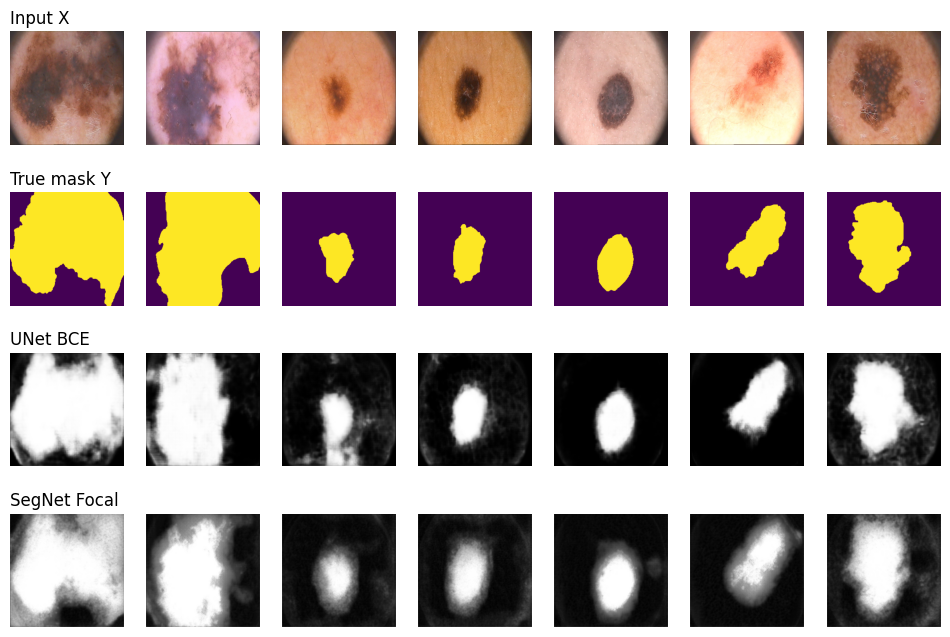

In [96]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def eval_using_cp(cp, model, X):
    checkpoint = torch.load(cp, map_location=DEVICE)
    model = model().to(DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    with torch.no_grad():
        preds = model(X.to(DEVICE))
        preds = torch.sigmoid(preds).cpu().numpy()
    return preds

X_tensor = torch.from_numpy(X[ts]).permute(0, 3, 1, 2).float()
preds_unet_bce = eval_using_cp('best_unet_model_bce.pth', model=UNet, X=X_tensor)
preds_segnet_focal = eval_using_cp('best_focal_model.pth', model=SegNet, X=X_tensor)

PICS = 7

plt.figure(figsize=(12, 8))
for i in range(PICS):
    x = X[ts][i]
    y = Y[ts][i]

    ax1 = plt.subplot(4, PICS, i+1)
    plt.axis("off")
    plt.imshow(x)

    ax2 = plt.subplot(4, PICS, i+1+PICS)
    plt.axis("off")
    plt.imshow(y)

    ax3 = plt.subplot(4, PICS, i + 1 + 2*PICS)
    plt.axis("off")
    plt.imshow(preds_unet_bce[i, 0], cmap="gray")

    ax4 = plt.subplot(4, PICS, i + 1 + 3*PICS)
    plt.axis("off")
    plt.imshow(preds_segnet_focal[i, 0], cmap="gray")

    if i == 0:
        ax1.set_title("Input X", loc="left")
        ax2.set_title("True mask Y", loc="left")
        ax3.set_title("UNet BCE", loc="left")
        ax4.set_title("SegNet Focal", loc="left")


plt.show()

cleanup_models()

Визуально видно, что UNet более уверенно предсказывает границы между объектом и фоном. SegNet же даёт более шумные предсказания и выход SegNet будет сильно варьироваться от выбора threshold. 

Как и ожидалось, наличие skip connection в UNet позволяет улавливать признаки и на микро и на макро уровнях, в итоге качество предсказаний весьма неплохое.